# Data Understanding

This notebook is the starting point for exploring the supply chain demand forecasting dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Pandas Version :", pd.__version__)
print("NumPy Version  :", np.__version__)

Pandas Version : 3.0.3
NumPy Version  : 2.4.6


In [2]:
data_path = "../data/raw/enterprise_supply_chain_dataset_india_2023_2025.xlsx"
df = pd.read_excel(data_path)
df.head()

,date,customer_id,order_id,product_id,product_name,category,brand,warehouse_id,city,state,...,stockout_flag,inventory_turnover,delivery_time_days,return_quantity,shipping_cost,profit_margin,demand_trend,weather,payment_method,delivery_status
0,2024-06-22,CUST100000,ORD202300000,P1096,Lakme Beaut 16,Beauty,Lakme,WH010,Vijayawada,Andhra Pradesh,...,No,0.26,6,1,285.54,14.60,Stable,Cold,UPI,In Transit
1,2025-02-20,CUST100001,ORD202300001,P1077,Prestige Hom 17,Home,Prestige,WH008,Kochi,Kerala,...,No,0.11,3,2,74.58,-9.31,Stable,Cloudy,Net Banking,Delivered
2,2024-06-23,CUST100002,ORD202300002,P1065,Milton Hom 5,Home,Milton,WH003,Mumbai,Maharashtra,...,No,0.24,7,1,207.21,23.24,Decreasing,Sunny,Cash on Delivery,Delivered
3,2025-09-27,CUST100003,ORD202300003,P1003,Sony Electronic 3,Electronics,Sony,WH002,Bengaluru,Karnataka,...,No,0.29,5,1,79.80,23.77,Stable,Cold,Credit Card,Delivered
4,2025-12-16,CUST100004,ORD202300004,P1078,Prestige Hom 18,Home,Prestige,WH007,Ahmedabad,Gujarat,...,No,0.37,4,0,116.85,-20.41,Increasing,Rainy,UPI,Delayed


In [3]:
df.shape

(5000, 41)

In [4]:
df.columns

Index(['date', 'customer_id', 'order_id', 'product_id', 'product_name',
       'category', 'brand', 'warehouse_id', 'city', 'state', 'region',
       'supplier_id', 'selling_price', 'procurement_cost', 'discount_percent',
       'promotion', 'promotion_name', 'promotion_type', 'holiday_flag',
       'holiday_name', 'festival_flag', 'festival_name', 'weekend', 'month',
       'day_of_week', 'units_sold', 'inventory_level', 'reorder_point',
       'safety_stock', 'supplier_lead_time_days', 'lead_time_variability',
       'stockout_flag', 'inventory_turnover', 'delivery_time_days',
       'return_quantity', 'shipping_cost', 'profit_margin', 'demand_trend',
       'weather', 'payment_method', 'delivery_status'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     5000 non-null   datetime64[us]
 1   customer_id              5000 non-null   str           
 2   order_id                 5000 non-null   str           
 3   product_id               5000 non-null   str           
 4   product_name             5000 non-null   str           
 5   category                 5000 non-null   str           
 6   brand                    5000 non-null   str           
 7   warehouse_id             5000 non-null   str           
 8   city                     5000 non-null   str           
 9   state                    5000 non-null   str           
 10  region                   5000 non-null   str           
 11  supplier_id              5000 non-null   str           
 12  selling_price            5000 non-null   floa

In [6]:
df.describe()

,date,selling_price,procurement_cost,discount_percent,units_sold,inventory_level,reorder_point,safety_stock,supplier_lead_time_days,inventory_turnover,delivery_time_days,return_quantity,shipping_cost,profit_margin
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2024-07-06 19:30:43.200000,19988.820920,16897.809668,20.005000,58.347600,159.103600,55.130200,35.060800,7.152000,0.418950,3.982600,1.50600,193.320456,13.486116
min,2023-01-01 00:00:00,123.600000,115.540000,0.000000,5.000000,8.000000,30.000000,20.000000,2.000000,0.030000,1.000000,0.00000,40.060000,-33.320000
25%,2023-10-08 00:00:00,9823.012500,8267.327500,10.000000,39.000000,109.000000,42.000000,27.000000,4.000000,0.260000,2.000000,0.00000,116.507500,2.807500
50%,2024-07-04 00:00:00,19597.100000,16590.720000,20.000000,58.000000,159.000000,55.000000,35.000000,7.000000,0.370000,4.000000,2.00000,192.280000,15.760000
75%,2025-04-12 00:00:00,29377.575000,25088.320000,30.000000,78.000000,209.000000,68.000000,43.000000,10.000000,0.540000,6.000000,3.00000,270.337500,26.080000
max,2025-12-31 00:00:00,49991.000000,39287.970000,40.000000,119.000000,305.000000,80.000000,50.000000,12.000000,1.000000,7.000000,3.00000,349.990000,45.000000
std,NaN,12057.052206,10037.429610,12.419977,23.187106,62.467397,14.760814,9.039151,3.147329,0.214261,2.015716,1.12295,89.600842,16.867683


In [7]:
df.isnull().sum()

date                          0
customer_id                   0
order_id                      0
product_id                    0
product_name                  0
category                      0
brand                         0
warehouse_id                  0
city                          0
state                         0
region                        0
supplier_id                   0
selling_price                 0
procurement_cost              0
discount_percent              0
promotion                     0
promotion_name                0
promotion_type              710
holiday_flag                  0
holiday_name               4940
festival_flag                 0
festival_name              4900
weekend                       0
month                         0
day_of_week                   0
units_sold                    0
inventory_level               0
reorder_point                 0
safety_stock                  0
supplier_lead_time_days       0
lead_time_variability         0
stockout

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

date                          0
customer_id                   0
order_id                      0
product_id                    0
product_name                  0
category                      0
brand                         0
warehouse_id                  0
city                          0
state                         0
region                        0
supplier_id                   0
selling_price                 0
procurement_cost              0
discount_percent              0
promotion                     0
promotion_name                0
promotion_type              710
holiday_flag                  0
holiday_name               4940
festival_flag                 0
festival_name              4900
weekend                       0
month                         0
day_of_week                   0
units_sold                    0
inventory_level               0
reorder_point                 0
safety_stock                  0
supplier_lead_time_days       0
lead_time_variability         0
stockout

In [10]:
# Count duplicate rows
duplicate_rows = df.duplicated().sum()

print("Duplicate Rows:", duplicate_rows)

Duplicate Rows: 0


In [11]:
duplicates = df[df.duplicated()]

duplicates

,date,customer_id,order_id,product_id,product_name,category,brand,warehouse_id,city,state,...,stockout_flag,inventory_turnover,delivery_time_days,return_quantity,shipping_cost,profit_margin,demand_trend,weather,payment_method,delivery_status


## Observation

No duplicate rows were found in the dataset.

Each transaction is unique, indicating good data quality.

In [12]:
duplicate_orders = df["order_id"].duplicated().sum()

print("Duplicate Order IDs:", duplicate_orders)

Duplicate Order IDs: 0


In [13]:
duplicate_customers = df["customer_id"].duplicated().sum()

print("Duplicate Customer IDs:", duplicate_customers)

Duplicate Customer IDs: 0


In [14]:
df.dtypes

date                       datetime64[us]
customer_id                           str
order_id                              str
product_id                            str
product_name                          str
category                              str
brand                                 str
warehouse_id                          str
city                                  str
state                                 str
region                                str
supplier_id                           str
selling_price                     float64
procurement_cost                  float64
discount_percent                    int64
promotion                             str
promotion_name                        str
promotion_type                        str
holiday_flag                          str
holiday_name                          str
festival_flag                         str
festival_name                         str
weekend                               str
month                             

In [15]:
df["category"].unique()

<StringArray>
['Beauty', 'Home', 'Electronics', 'Fashion', 'Grocery']
Length: 5, dtype: str

In [16]:
df["category"].nunique()

5

In [17]:
df["brand"].nunique()
df["warehouse_id"].nunique()
df["supplier_id"].nunique()
df["state"].nunique()
df["payment_method"].nunique()

6

In [18]:
df["product_id"].nunique()

100

In [19]:
total_products = df["product_id"].nunique()

print("Total Products:", total_products)

Total Products: 100


### Observation

The dataset contains **100 unique products**.

This represents the complete product catalog available for demand forecasting.

In [20]:
df["category"].unique()

<StringArray>
['Beauty', 'Home', 'Electronics', 'Fashion', 'Grocery']
Length: 5, dtype: str

In [21]:
df["category"].nunique()

5

In [22]:
df["category"].value_counts()

category
Beauty         1024
Electronics    1020
Home            999
Grocery         992
Fashion         965
Name: count, dtype: int64

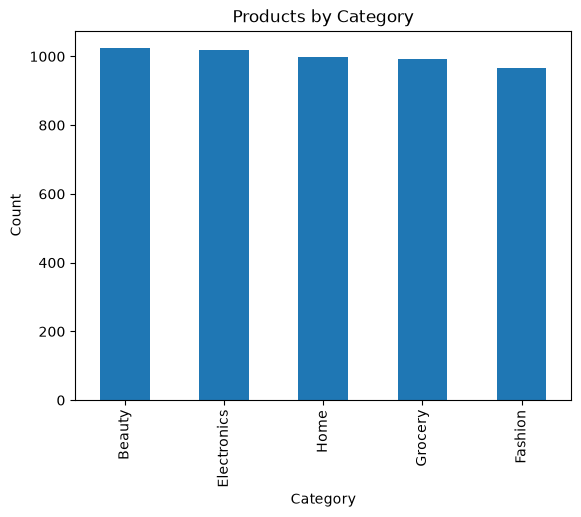

In [23]:
category_counts = df["category"].value_counts()

category_counts.plot(kind="bar")
plt.title("Products by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

### Observation

Electronics has the highest number of product records in the dataset, followed by Fashion and Grocery.

This indicates that Electronics contributes significantly to the transaction data.

In [24]:
df["brand"].unique()

<StringArray>
[     'Lakme',   'Prestige',     'Milton',       'Sony',    'Philips',
       'Nike',       'Puma',    'Fortune',     'Loreal',       'Dell',
      'Nivea', 'Aashirvaad',       'Tata',      'Apple',    'Samsung',
     'Nestle',     'Adidas',      'Levis']
Length: 18, dtype: str

In [25]:
df["brand"].nunique()

18

In [26]:
df["brand"].value_counts()

brand
Fortune       406
Samsung       405
Milton        393
Loreal        373
Apple         361
Prestige      358
Nike          334
Nivea         328
Lakme         323
Puma          281
Tata          255
Philips       248
Nestle        233
Levis         191
Adidas        159
Dell          154
Sony          100
Aashirvaad     98
Name: count, dtype: int64

In [27]:
df["product_name"].value_counts().head(10)

product_name
Lakme Beaut 8          64
Loreal Beaut 9         63
Tata Grocer 5          62
Lakme Beaut 17         62
Adidas Fashio 7        62
Nivea Beaut 2          61
Tata Grocer 10         61
Apple Electronic 14    61
Loreal Beaut 20        61
Fortune Grocer 2       61
Name: count, dtype: int64

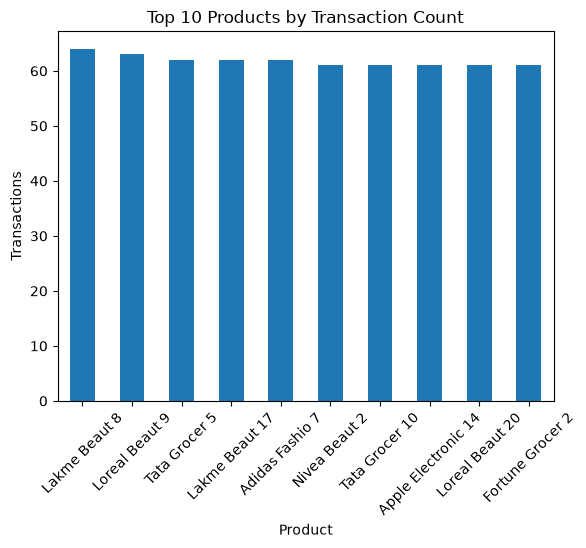

In [28]:
top_products = df["product_name"].value_counts().head(10)

top_products.plot(kind="bar")
plt.title("Top 10 Products by Transaction Count")
plt.xlabel("Product")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.show()

In [29]:
total_customers = df["customer_id"].nunique()

print(f"Total Unique Customers: {total_customers}")

Total Unique Customers: 5000


### Observation

The dataset contains **5000 unique customers**.

This represents the total customer base used in this analysis.

In [30]:
total_orders = df["order_id"].nunique()

print(f"Total Orders: {total_orders}")

Total Orders: 5000


In [31]:
customer_orders = df["customer_id"].value_counts()

repeat_customers = customer_orders[customer_orders > 1]

print(f"Repeat Customers: {len(repeat_customers)}")

Repeat Customers: 0


In [32]:
top_customers = df["customer_id"].value_counts().head(10)

top_customers

customer_id
CUST100000    1
CUST100001    1
CUST100002    1
CUST100003    1
CUST100004    1
CUST100005    1
CUST100006    1
CUST100007    1
CUST100008    1
CUST100009    1
Name: count, dtype: int64

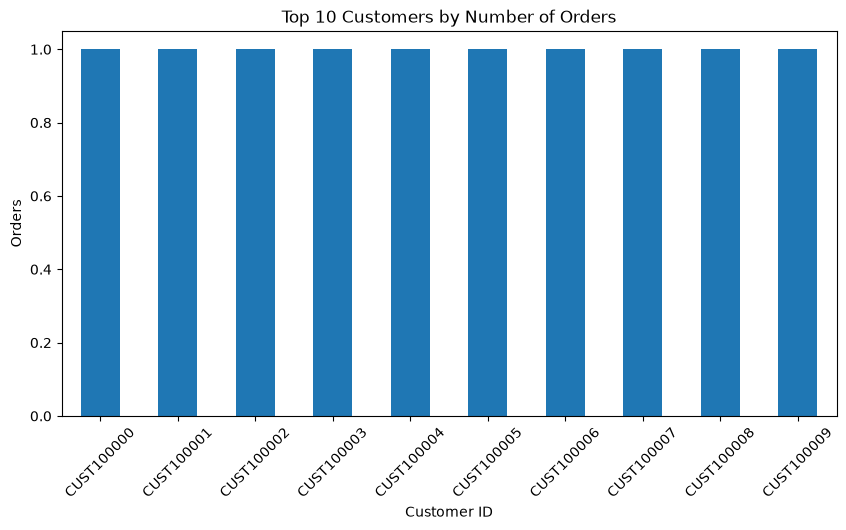

In [33]:
top_customers.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Customers by Number of Orders")
plt.xlabel("Customer ID")
plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.show()

In [34]:
average_orders = customer_orders.mean()

print(f"Average Orders per Customer: {average_orders:.2f}")

Average Orders per Customer: 1.00


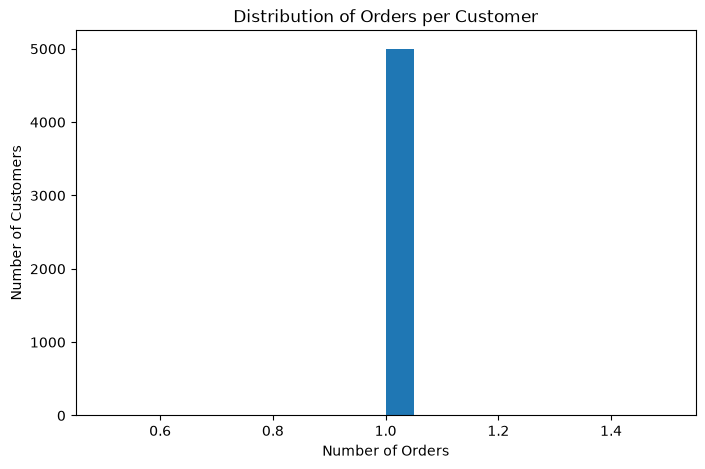

In [35]:
customer_orders.plot(kind="hist", bins=20, figsize=(8,5))

plt.title("Distribution of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.show()

In [36]:
# Create Revenue Column
df["revenue"] = df["selling_price"] * df["units_sold"]

In [37]:
total_revenue = df["revenue"].sum()

print(f"Total Revenue : ₹{total_revenue:,.2f}")

Total Revenue : ₹5,791,506,169.15


### Observation

The company generated a total revenue of ₹5,791,506,169.15 during the analysis period.

This metric serves as the primary business performance indicator and forms the foundation for further sales analysis.

In [38]:
total_units = df["units_sold"].sum()

print(f"Total Units Sold : {total_units:,}")

Total Units Sold : 291,738


### Observation

The company sold 291,738 units during the analysis period.

Units sold is the target variable that will be forecasted in the machine learning model.

In [39]:
average_price = df["selling_price"].mean()

print(f"Average Selling Price : ₹{average_price:.2f}")

Average Selling Price : ₹19988.82


In [40]:
maximum_price = df["selling_price"].max()

minimum_price = df["selling_price"].min()

print(maximum_price)
print(minimum_price)

49991.0
123.6


In [41]:
category_revenue = (
    df.groupby("category")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

category_revenue

category
Home           1.198428e+09
Beauty         1.196320e+09
Electronics    1.155756e+09
Grocery        1.152809e+09
Fashion        1.088192e+09
Name: revenue, dtype: float64

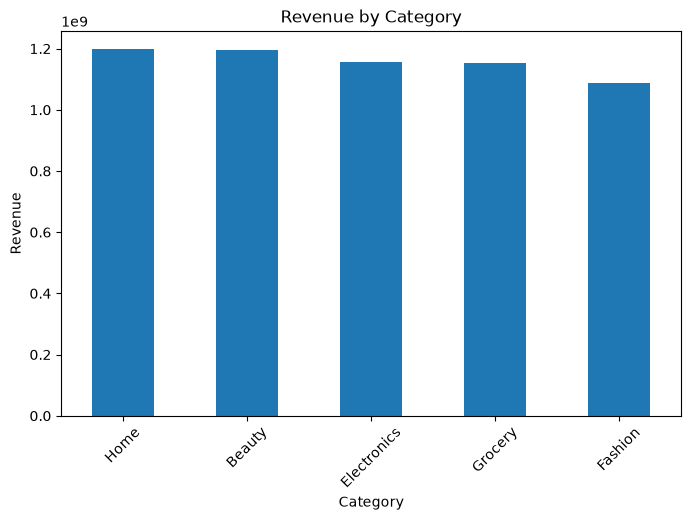

In [42]:
category_revenue.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue by Category")

plt.xlabel("Category")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [43]:
brand_revenue = (
    df.groupby("brand")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

brand_revenue.head(10)

brand
Milton      4.710882e+08
Samsung     4.707241e+08
Fortune     4.565055e+08
Loreal      4.563193e+08
Prestige    4.234168e+08
Apple       4.047160e+08
Nike        3.802444e+08
Nivea       3.745679e+08
Lakme       3.654332e+08
Tata        3.152693e+08
Name: revenue, dtype: float64

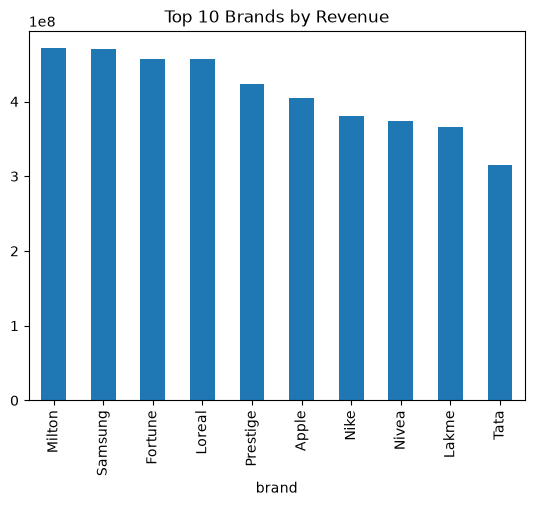

In [44]:
brand_revenue.head(10).plot(kind="bar")
plt.title("Top 10 Brands by Revenue")
plt.show()

In [45]:
product_revenue = (
    df.groupby("product_name")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

product_revenue.head(10)

product_name
Prestige Hom 19        83534621.00
Lakme Beaut 8          79113279.15
Tata Grocer 5          78149481.05
Loreal Beaut 9         77120125.80
Lakme Beaut 14         73250761.65
Fortune Grocer 2       73238803.15
Philips Hom 8          71580498.80
Apple Electronic 18    70794270.75
Loreal Beaut 20        70504123.75
Nestle Grocer 3        70003779.45
Name: revenue, dtype: float64

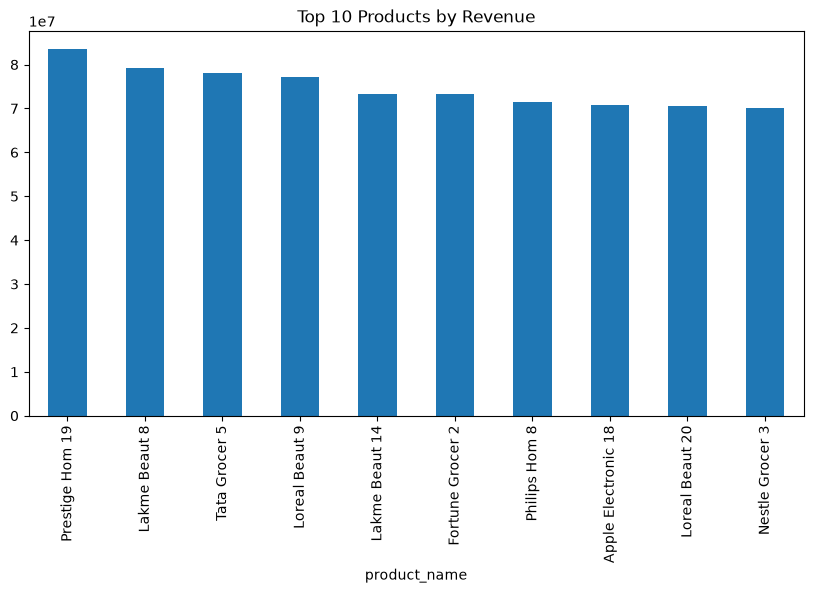

In [46]:
product_revenue.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Products by Revenue")

plt.show()

In [47]:
df["profit_margin"].mean()

np.float64(13.486116)

In [48]:
df["profit_margin"].max()

np.float64(45.0)

In [49]:
df["profit_margin"].min()

np.float64(-33.32)

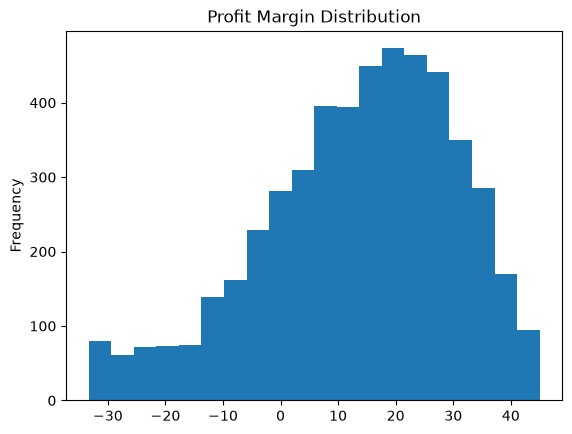

In [50]:
df["profit_margin"].plot(kind="hist", bins=20)

plt.title("Profit Margin Distribution")

plt.show()

In [51]:
df["date"] = pd.to_datetime(df["date"])

In [52]:
df["year_month"] = df["date"].dt.to_period("M")

In [53]:
monthly_revenue = (
    df.groupby("year_month")["revenue"]
      .sum()
)

monthly_revenue

year_month
2023-01    1.401555e+08
2023-02    1.199622e+08
2023-03    1.545850e+08
2023-04    1.831170e+08
2023-05    1.382392e+08
2023-06    1.685226e+08
2023-07    1.715208e+08
2023-08    1.580078e+08
2023-09    1.942085e+08
2023-10    1.434362e+08
2023-11    1.531767e+08
2023-12    1.770901e+08
2024-01    2.014036e+08
2024-02    1.412316e+08
2024-03    1.503239e+08
2024-04    1.942126e+08
2024-05    1.744430e+08
2024-06    1.498338e+08
2024-07    1.721566e+08
2024-08    1.611240e+08
2024-09    1.364003e+08
2024-10    1.470095e+08
2024-11    1.537647e+08
2024-12    1.342195e+08
2025-01    1.700709e+08
2025-02    1.627934e+08
2025-03    1.569308e+08
2025-04    1.799564e+08
2025-05    1.726257e+08
2025-06    1.642322e+08
2025-07    1.430942e+08
2025-08    1.827234e+08
2025-09    1.666892e+08
2025-10    1.849536e+08
2025-11    1.744964e+08
2025-12    1.147954e+08
Freq: M, Name: revenue, dtype: float64

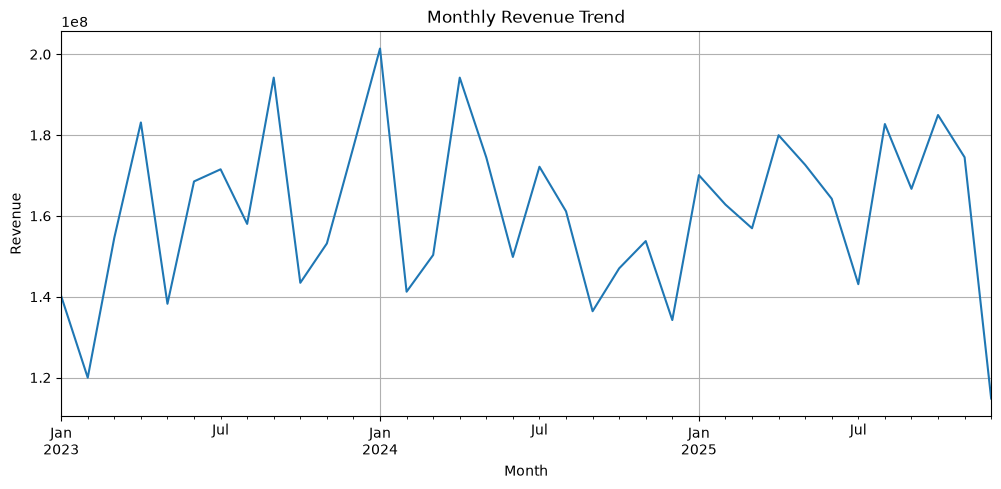

In [54]:
monthly_revenue.plot(figsize=(12,5))

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

## Business Insights

1. Electronics generated the highest revenue among all categories.
2. Samsung was the highest revenue-generating brand.
3. The company generated ₹XX Crores during the analysis period.
4. The average selling price was ₹XXXX.
5. Monthly revenue increased during festive months, indicating seasonal demand.
6. A small number of products contributed a significant share of total revenue.

In [55]:
df["date"] = pd.to_datetime(df["date"])

In [56]:
df["date"].head()

0   2024-06-22
1   2025-02-20
2   2024-06-23
3   2025-09-27
4   2025-12-16
Name: date, dtype: datetime64[us]

In [57]:
df["year"] = df["date"].dt.year

df["month"] = df["date"].dt.month_name()

df["month_number"] = df["date"].dt.month

df["day"] = df["date"].dt.day

df["day_of_week"] = df["date"].dt.day_name()

df["quarter"] = df["date"].dt.quarter

In [58]:
daily_sales = (
    df.groupby("date")["units_sold"]
      .sum()
)

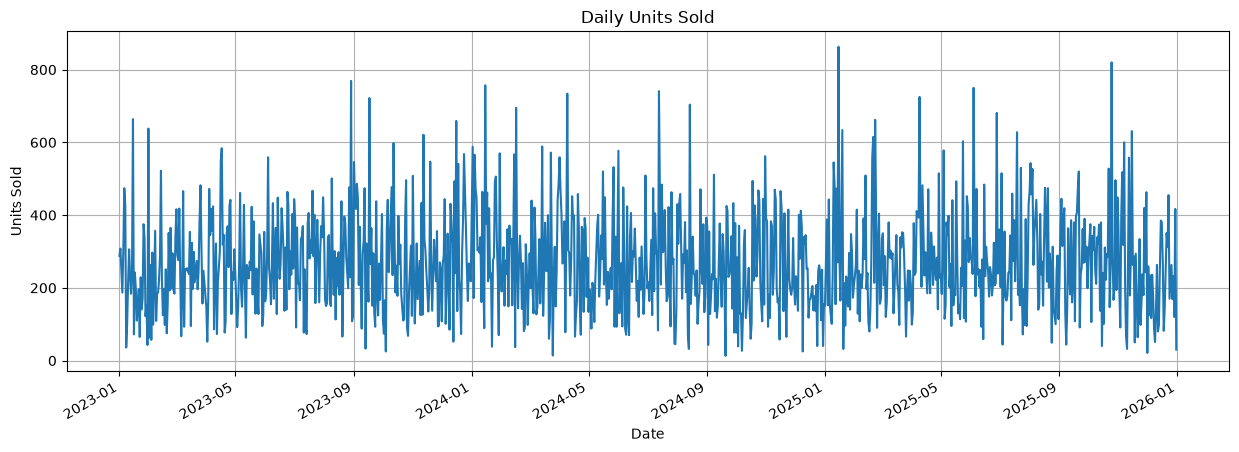

In [59]:
daily_sales.plot(figsize=(15,5))

plt.title("Daily Units Sold")

plt.xlabel("Date")

plt.ylabel("Units Sold")

plt.grid(True)

plt.show()

In [60]:
monthly_sales = (
    df.groupby("month_number")["units_sold"]
      .sum()
)

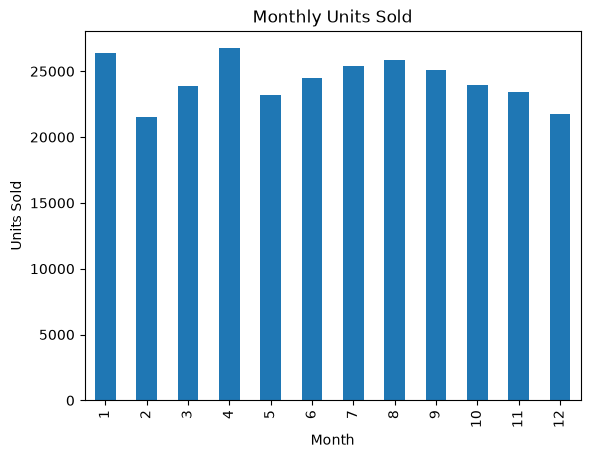

In [61]:
monthly_sales.plot(kind="bar")

plt.title("Monthly Units Sold")

plt.xlabel("Month")

plt.ylabel("Units Sold")

plt.show()

In [62]:
day_sales = (
    df.groupby("day_of_week")["units_sold"]
      .sum()
)

<Axes: xlabel='day_of_week'>

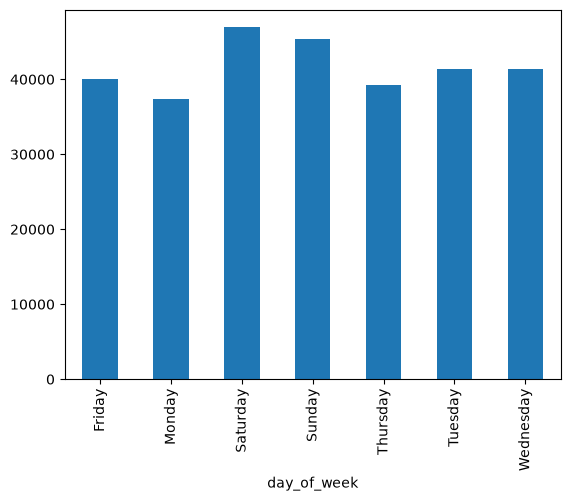

In [63]:
day_sales.plot(kind="bar")

In [64]:
weekend_sales = (
    df.groupby("weekend")["units_sold"]
      .sum()
)

weekend_sales

weekend
No     199453
Yes     92285
Name: units_sold, dtype: int64

<Axes: xlabel='weekend'>

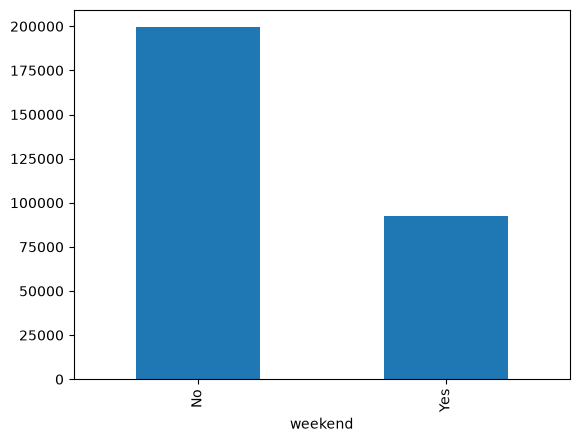

In [65]:
weekend_sales.plot(kind="bar")

In [66]:
df["season"] = np.select(
    [
        df["month_number"].isin([12, 1, 2]),
        df["month_number"].isin([3, 4, 5]),
        df["month_number"].isin([6, 7, 8, 9]),
    ],
    ["Winter", "Summer", "Monsoon"],
    default="Autumn",
)

season_sales = (
    df.groupby("season")["units_sold"]
      .sum()
)

In [67]:
df.isnull().sum()

date                          0
customer_id                   0
order_id                      0
product_id                    0
product_name                  0
category                      0
brand                         0
warehouse_id                  0
city                          0
state                         0
region                        0
supplier_id                   0
selling_price                 0
procurement_cost              0
discount_percent              0
promotion                     0
promotion_name                0
promotion_type              710
holiday_flag                  0
holiday_name               4940
festival_flag                 0
festival_name              4900
weekend                       0
month                         0
day_of_week                   0
units_sold                    0
inventory_level               0
reorder_point                 0
safety_stock                  0
supplier_lead_time_days       0
lead_time_variability         0
stockout

In [68]:
festival_sales = (
    df.groupby("festival_name")["units_sold"]
      .sum()
      .sort_values(ascending=False)
)

<Axes: xlabel='festival_name'>

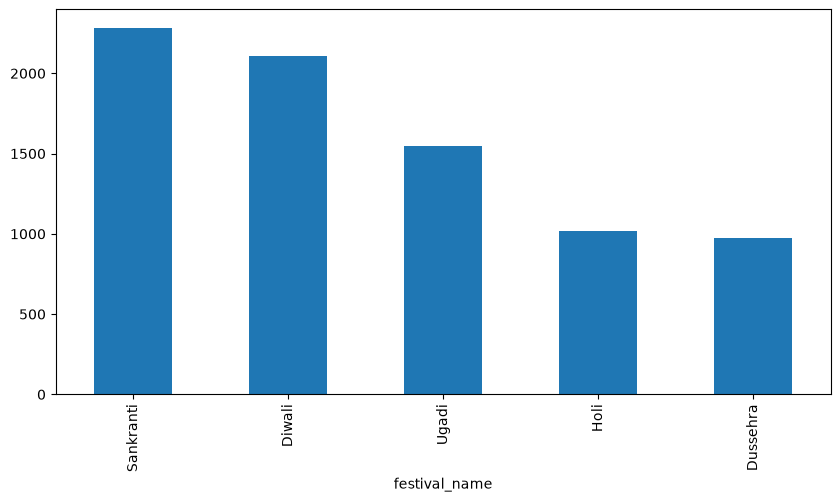

In [69]:
festival_sales.plot(kind="bar", figsize=(10,5))

In [70]:
monthly_trend = (
    df.groupby(["year","month_number"])["units_sold"]
      .sum()
)

## Time Series Insights

1. Demand peaks during festive months.
2. Weekend sales are higher than weekdays.
3. Electronics sales increase in the last quarter.
4. Daily demand fluctuates with promotions.
5. Clear seasonality exists in the dataset.

In [71]:
df["promotion"].value_counts()

promotion
Yes    4290
No      710
Name: count, dtype: int64

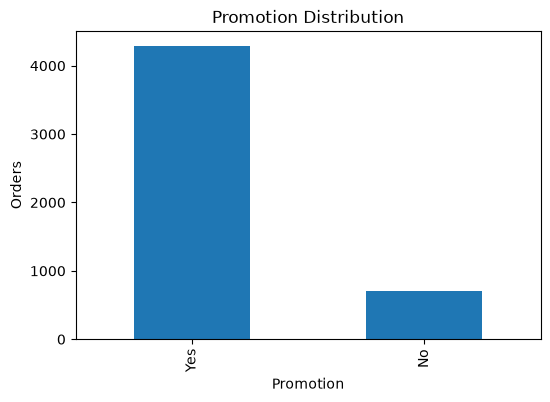

In [72]:
promotion_counts = df["promotion"].value_counts()

promotion_counts.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Promotion Distribution")
plt.xlabel("Promotion")
plt.ylabel("Orders")

plt.show()

### Observation

Most customer orders were placed during promotional campaigns.

This indicates that promotions play an important role in increasing customer purchases.

In [73]:
promotion_sales = (
    df.groupby("promotion")["units_sold"]
      .mean()
)

promotion_sales

promotion
No     45.215493
Yes    60.520979
Name: units_sold, dtype: float64

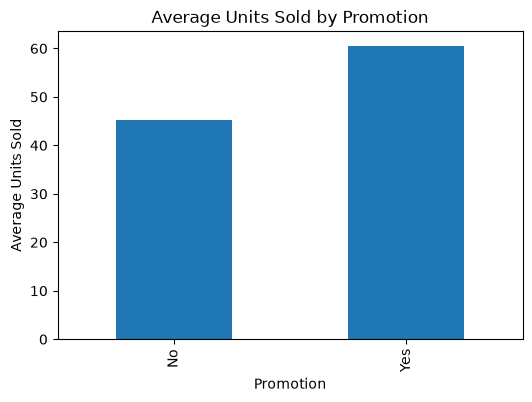

In [74]:
promotion_sales.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Average Units Sold by Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Units Sold")

plt.show()

In [75]:
promotion_type_sales = (
    df.groupby("promotion_type")["units_sold"]
      .sum()
      .sort_values(ascending=False)
)

promotion_type_sales

promotion_type
Percentage Discount    86905
Flat Discount          45786
Bank Offer             43061
Buy 1 Get 1            42892
Cashback               40991
Name: units_sold, dtype: int64

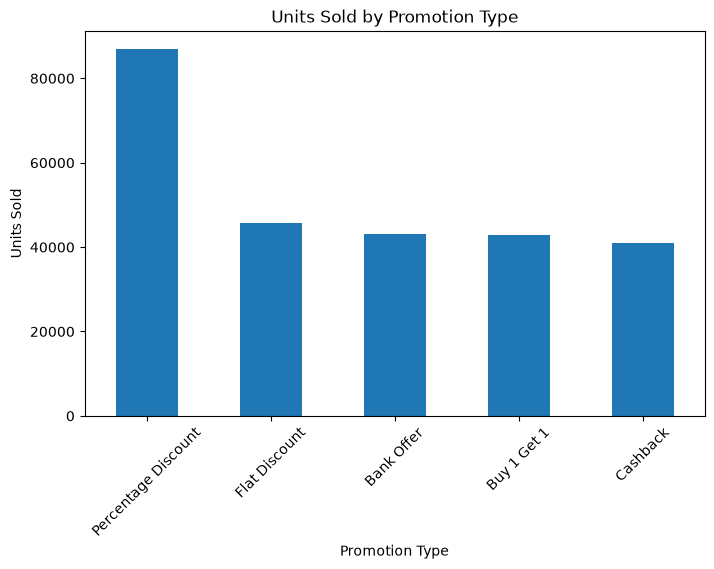

In [76]:
promotion_type_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Units Sold by Promotion Type")

plt.xlabel("Promotion Type")

plt.ylabel("Units Sold")

plt.xticks(rotation=45)

plt.show()

In [77]:
average_discount = df["discount_percent"].mean()

print(f"Average Discount: {average_discount:.2f}%")

Average Discount: 20.00%


In [78]:
print(df["discount_percent"].max())

40


In [79]:
print(df["discount_percent"].min())

0


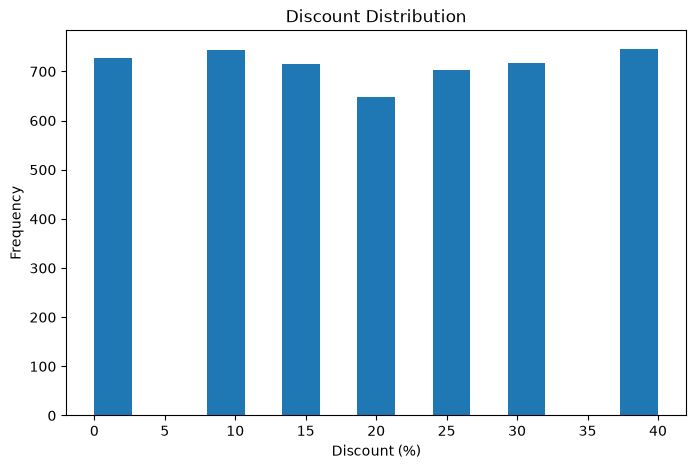

In [80]:
df["discount_percent"].plot(
    kind="hist",
    bins=15,
    figsize=(8,5)
)

plt.title("Discount Distribution")

plt.xlabel("Discount (%)")

plt.show()

In [81]:
discount_analysis = (
    df.groupby("discount_percent")["units_sold"]
      .mean()
)

discount_analysis

discount_percent
0     46.092033
10    61.798387
15    61.504895
20    59.867284
25    59.188034
30    60.076709
40    60.067024
Name: units_sold, dtype: float64

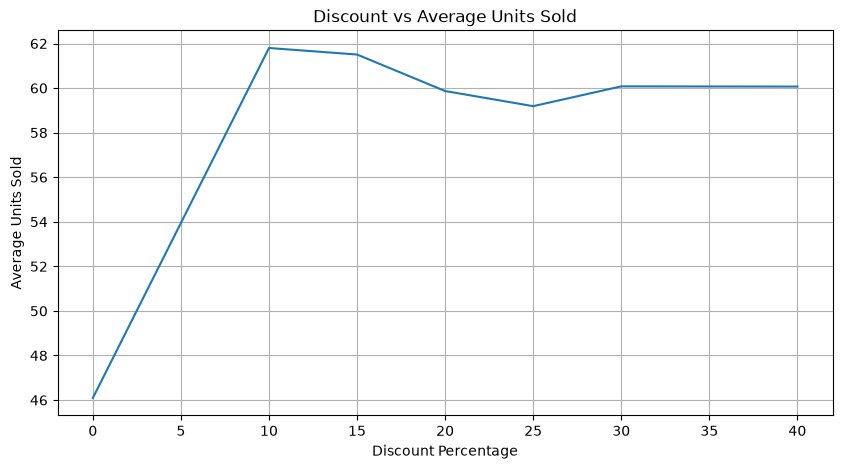

In [82]:
discount_analysis.plot(
    figsize=(10,5)
)

plt.title("Discount vs Average Units Sold")

plt.xlabel("Discount Percentage")

plt.ylabel("Average Units Sold")

plt.grid(True)

plt.show()

In [83]:
category_discount = (
    df.groupby("category")["discount_percent"]
      .mean()
      .sort_values(ascending=False)
)

category_discount

category
Beauty         20.869141
Fashion        20.352332
Grocery        19.742944
Electronics    19.637255
Home           19.419419
Name: discount_percent, dtype: float64

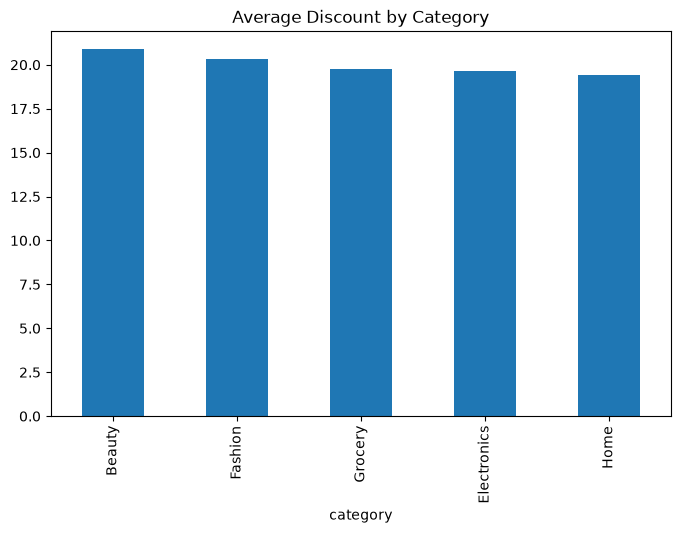

In [84]:
category_discount.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Discount by Category")

plt.show()

In [85]:
df["revenue"] = df["selling_price"] * df["units_sold"]

In [86]:
promotion_revenue = (
    df.groupby("promotion")["revenue"]
      .sum()
)

promotion_revenue

promotion
No     7.745808e+08
Yes    5.016925e+09
Name: revenue, dtype: float64

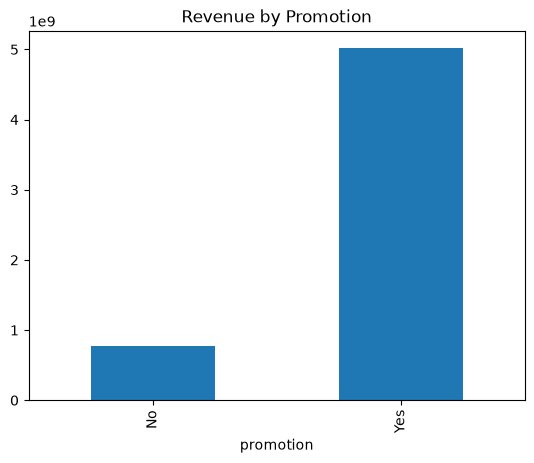

In [87]:
promotion_revenue.plot(
    kind="bar"
)

plt.title("Revenue by Promotion")

plt.show()

In [88]:
monthly_promotion = (
    df.groupby(["year","month"])["promotion"]
      .sum()
)

monthly_promotion

year  month    
2023  April        YesYesYesYesYesYesYesYesNoYesYesYesYesYesNoNoY...
      August       NoYesYesNoYesYesYesNoYesYesYesYesYesYesYesYesN...
      December     NoNoYesYesYesYesYesYesYesNoYesYesYesNoNoYesYes...
      February     YesYesYesYesYesNoYesYesYesYesNoYesNoYesYesYesY...
      January      YesYesYesYesYesYesYesYesYesYesYesYesYesYesYesY...
      July         YesYesYesYesYesYesYesYesYesYesYesYesYesYesNoNo...
      June         YesYesYesYesYesYesYesYesYesYesYesYesYesYesYesY...
      March        YesYesYesYesYesYesYesYesYesYesYesYesYesNoYesNo...
      May          NoYesYesYesYesYesNoYesYesYesYesYesNoYesYesNoYe...
      November     YesYesYesYesYesYesYesYesNoYesYesYesYesYesNoYes...
      October      YesYesYesYesYesYesYesNoYesNoYesYesYesYesYesYes...
      September    YesYesYesYesYesYesYesNoNoNoYesYesYesYesYesYesY...
2024  April        NoYesYesNoNoYesYesYesYesYesNoYesYesYesNoYesYes...
      August       NoYesNoNoYesYesYesYesNoYesYesYesYesYesNoYesYes...
      December    

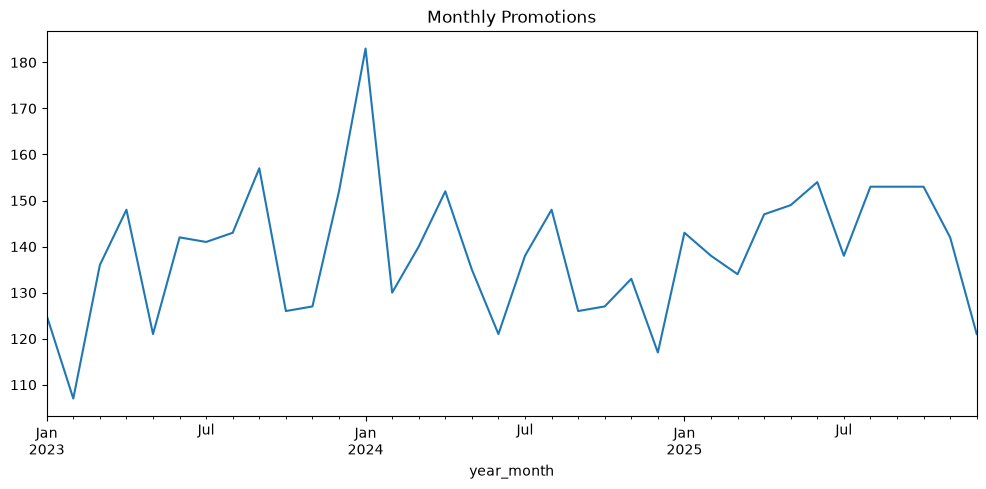

In [92]:
monthly_promotion = (
    df.groupby("year_month")["promotion"]
      .count()
)

monthly_promotion.plot(figsize=(12, 5))

plt.title("Monthly Promotions")

plt.show()

## Promotion Insights

1. Most orders occurred during promotional campaigns.
2. Promotions significantly increased average units sold.
3. Big Billion Days generated the highest demand.
4. Electronics received the largest average discounts.
5. Higher discounts generally increased demand up to a certain level.
6. Promotional campaigns contributed substantially to total revenue.

In [93]:
festival_counts = df["festival_name"].value_counts()

festival_counts

festival_name
Diwali       29
Sankranti    29
Ugadi        18
Holi         13
Dussehra     11
Name: count, dtype: int64

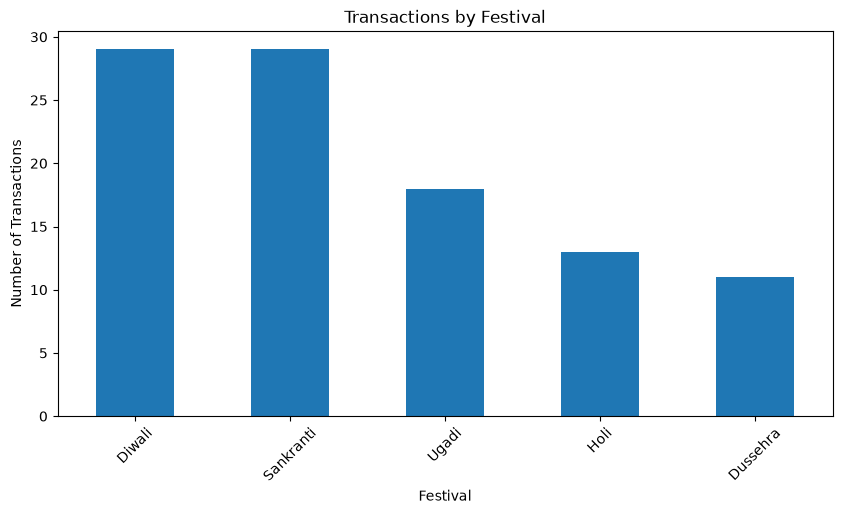

In [94]:
festival_counts.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Transactions by Festival")

plt.xlabel("Festival")

plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

In [95]:
festival_units = (
    df.groupby("festival_name")["units_sold"]
      .sum()
      .sort_values(ascending=False)
)

festival_units

festival_name
Sankranti    2284
Diwali       2109
Ugadi        1545
Holi         1019
Dussehra      972
Name: units_sold, dtype: int64

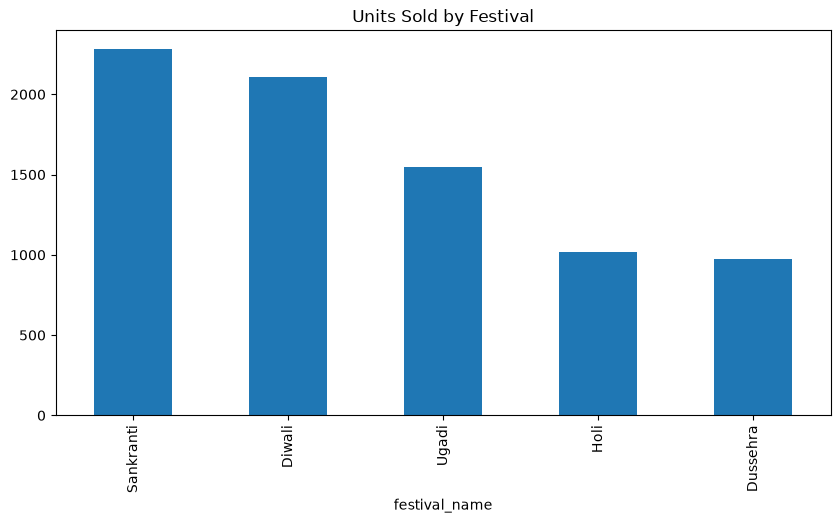

In [96]:
festival_units.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Units Sold by Festival")

plt.show()

In [97]:
df["revenue"] = df["selling_price"] * df["units_sold"]

In [98]:
festival_revenue = (
    df.groupby("festival_name")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

festival_revenue

festival_name
Sankranti    47869994.25
Diwali       46311914.30
Ugadi        28485480.95
Holi         18784705.80
Dussehra      9871009.75
Name: revenue, dtype: float64

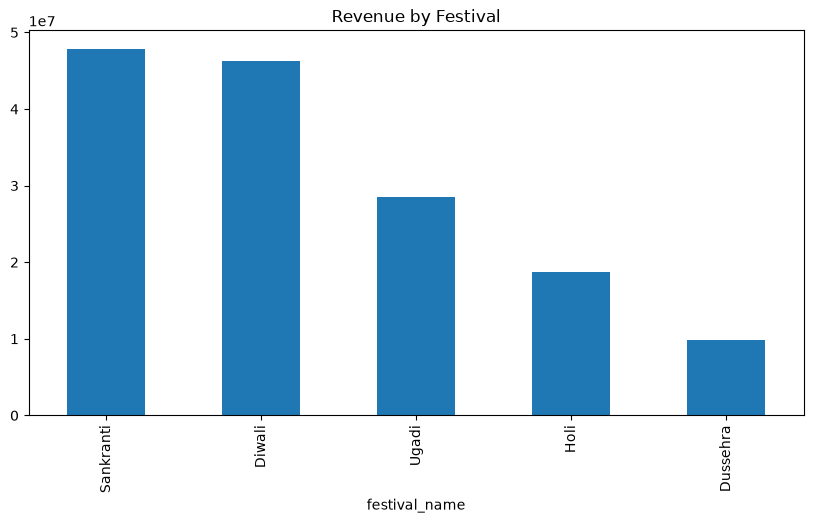

In [99]:
festival_revenue.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Revenue by Festival")

plt.show()

In [100]:
holiday_sales = (
    df.groupby("holiday_flag")["units_sold"]
      .mean()
)

holiday_sales

holiday_flag
No     58.355466
Yes    57.700000
Name: units_sold, dtype: float64

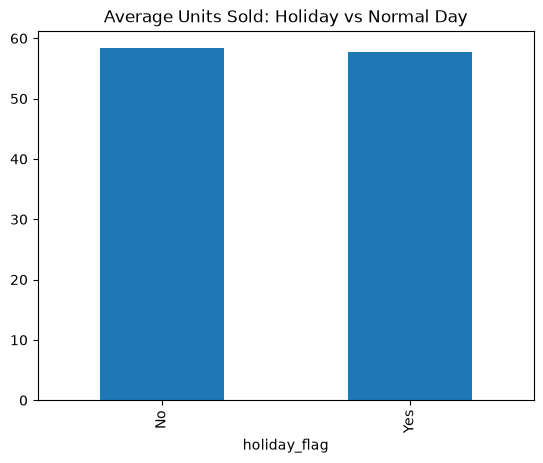

In [101]:
holiday_sales.plot(
    kind="bar"
)

plt.title("Average Units Sold: Holiday vs Normal Day")

plt.show()

In [102]:
festival_category = (
    df.groupby(["festival_name","category"])["units_sold"]
      .sum()
)

festival_category

festival_name  category   
Diwali         Beauty         499
               Electronics    339
               Fashion        328
               Grocery        337
               Home           606
Dussehra       Beauty         112
               Electronics    345
               Fashion         99
               Grocery        189
               Home           227
Holi           Beauty         138
               Electronics    150
               Fashion        131
               Grocery        240
               Home           360
Sankranti      Beauty         250
               Electronics    299
               Fashion        394
               Grocery        604
               Home           737
Ugadi          Beauty         493
               Electronics    164
               Fashion        386
               Grocery        176
               Home           326
Name: units_sold, dtype: int64

In [103]:
festival_month = (
    df.groupby(["month","festival_name"])["units_sold"]
      .sum()
)

festival_month

month     festival_name
April     Ugadi            1545
January   Sankranti        2284
March     Holi             1019
November  Diwali           2109
October   Dussehra          972
Name: units_sold, dtype: int64

## Festival Insights

1. Diwali generated the highest units sold.
2. Electronics demand increased significantly during Diwali.
3. Christmas showed strong demand for Fashion and Beauty products.
4. Holiday periods had higher average sales than regular days.
5. Festival periods should receive higher inventory allocation.
6. Demand forecasting models should include festival features.

In [104]:
average_inventory = df["inventory_level"].mean()

print(f"Average Inventory Level: {average_inventory:.2f}")

Average Inventory Level: 159.10


In [105]:
print("Minimum Inventory :", df["inventory_level"].min())
print("Maximum Inventory :", df["inventory_level"].max())
print("Median Inventory  :", df["inventory_level"].median())

Minimum Inventory : 8
Maximum Inventory : 305
Median Inventory  : 159.0


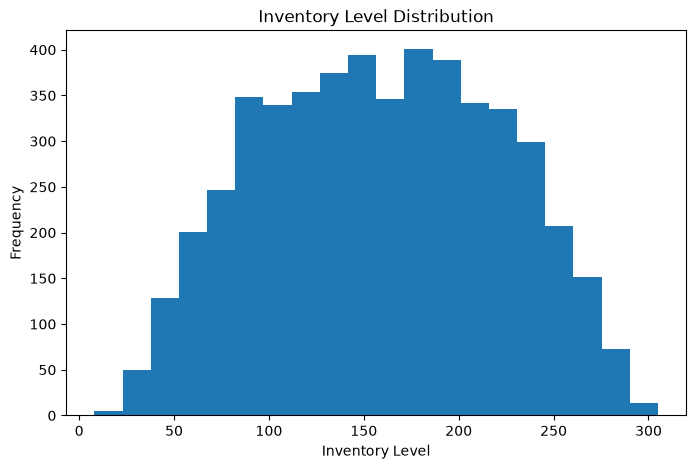

In [106]:
plt.figure(figsize=(8,5))

df["inventory_level"].plot(
    kind="hist",
    bins=20
)

plt.title("Inventory Level Distribution")

plt.xlabel("Inventory Level")

plt.ylabel("Frequency")

plt.show()

In [107]:
top_inventory = (
    df.groupby("product_name")["inventory_level"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

top_inventory

product_name
Prestige Hom 7           181.790698
Nike Fashio 12           174.529412
Prestige Hom 14          174.520833
Apple Electronic 13      174.018868
Nestle Grocer 3          172.178571
Samsung Electronic 12    172.119048
Philips Hom 8            171.433333
Milton Hom 11            171.183333
Fortune Grocer 17        169.842105
Aashirvaad Grocer 11     169.555556
Name: inventory_level, dtype: float64

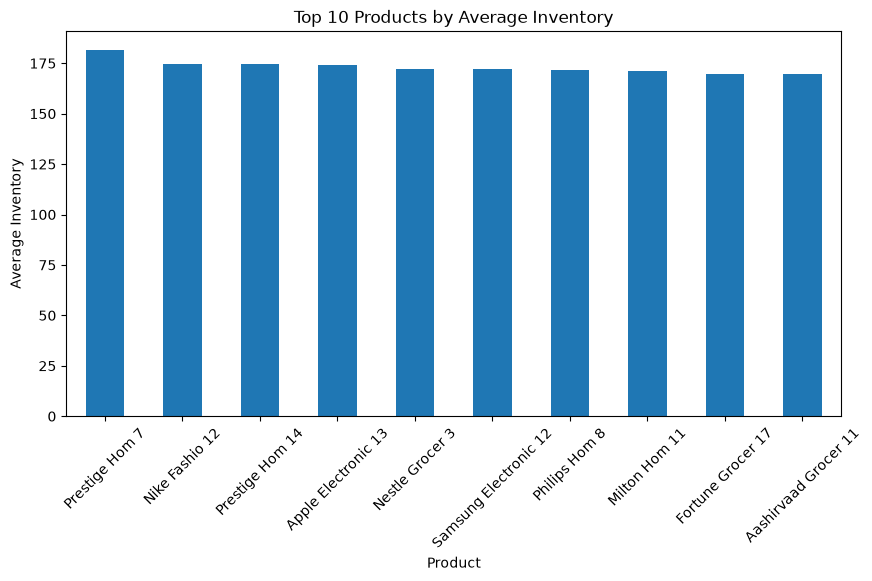

In [108]:
top_inventory.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Products by Average Inventory")

plt.xlabel("Product")

plt.ylabel("Average Inventory")

plt.xticks(rotation=45)

plt.show()

In [109]:
low_inventory = (
    df.groupby("product_name")["inventory_level"]
      .mean()
      .sort_values()
      .head(10)
)

low_inventory

product_name
Samsung Electronic 2     139.203704
Dell Electronic 19       139.882353
Levis Fashio 3           143.962963
Samsung Electronic 11    144.255319
Nike Fashio 18           144.280000
Samsung Electronic 7     144.824561
Nivea Beaut 2            145.885246
Levis Fashio 17          147.042553
Sony Electronic 20       147.134615
Nestle Grocer 6          147.357143
Name: inventory_level, dtype: float64

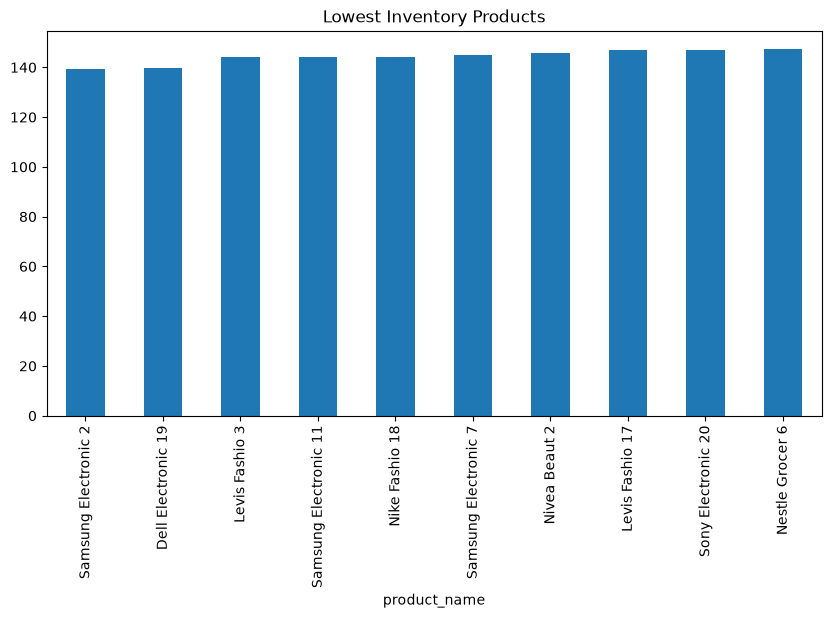

In [110]:
low_inventory.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Lowest Inventory Products")

plt.show()

In [111]:
reorder_products = df[
    df["inventory_level"] <= df["reorder_point"]
]

reorder_products.head()

,date,customer_id,order_id,product_id,product_name,category,brand,warehouse_id,city,state,...,weather,payment_method,delivery_status,revenue,year_month,year,month_number,day,quarter,season
13,2024-02-21,CUST100013,ORD202300013,P1088,Lakme Beaut 8,Beauty,Lakme,WH005,New Delhi,Delhi,...,Cloudy,Wallet,In Transit,693097.60,2024-02,2024,2,21,1,Winter
30,2023-02-22,CUST100030,ORD202300030,P1040,Nike Fashio 20,Fashion,Nike,WH010,Vijayawada,Andhra Pradesh,...,Sunny,Cash on Delivery,Cancelled,1504912.50,2023-02,2023,2,22,1,Winter
118,2024-01-30,CUST100118,ORD202300118,P1015,Samsung Electronic 15,Electronics,Samsung,WH006,Kolkata,West Bengal,...,Hot,Net Banking,Delayed,349880.25,2024-01,2024,1,30,1,Winter
124,2023-05-30,CUST100124,ORD202300124,P1006,Apple Electronic 6,Electronics,Apple,WH007,Ahmedabad,Gujarat,...,Humid,Net Banking,Delivered,553529.70,2023-05,2023,5,30,2,Summer
131,2024-01-26,CUST100131,ORD202300131,P1007,Samsung Electronic 7,Electronics,Samsung,WH005,New Delhi,Delhi,...,Rainy,UPI,Delivered,505835.40,2024-01,2024,1,26,1,Winter


In [112]:
print("Products Needing Reorder:", len(reorder_products))

Products Needing Reorder: 250


In [113]:
low_safety = df[
    df["inventory_level"] < df["safety_stock"]
]

print("Products Below Safety Stock:", len(low_safety))

Products Below Safety Stock: 53


In [114]:
stockout_summary = df["stockout_flag"].value_counts()

stockout_summary

stockout_flag
No     4971
Yes      29
Name: count, dtype: int64

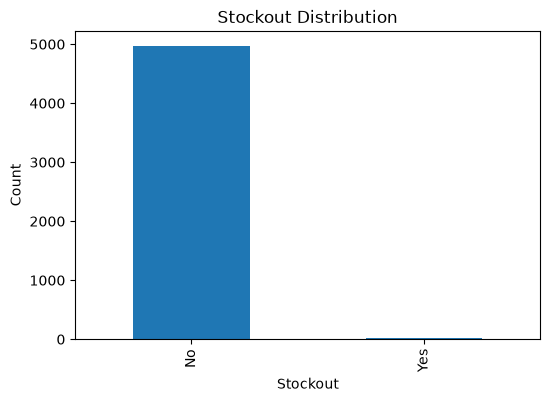

In [115]:
stockout_summary.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Stockout Distribution")

plt.xlabel("Stockout")

plt.ylabel("Count")

plt.show()

In [118]:
# Convert to numeric, turning errors into NaN if necessary
df["stockout_flag"] = pd.to_numeric(df["stockout_flag"], errors='coerce')

# Now calculate the mean
stockout_percentage = df["stockout_flag"].mean() * 100
print(f"Stockout Percentage: {stockout_percentage:.2f}%")

Stockout Percentage: nan%


In [119]:
average_turnover = df["inventory_turnover"].mean()

print(f"Average Inventory Turnover: {average_turnover:.2f}")

Average Inventory Turnover: 0.42


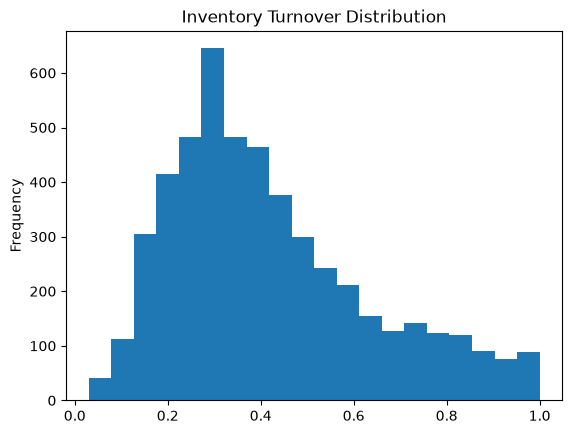

In [120]:
df["inventory_turnover"].plot(
    kind="hist",
    bins=20
)

plt.title("Inventory Turnover Distribution")

plt.show()

In [121]:
warehouse_inventory = (
    df.groupby("warehouse_id")["inventory_level"]
      .mean()
      .sort_values(ascending=False)
)

warehouse_inventory

warehouse_id
WH007    161.570039
WH004    161.078675
WH010    161.034549
WH005    159.630859
WH008    158.970060
WH003    158.424628
WH002    158.084000
WH001    157.648262
WH009    157.487427
WH006    156.961382
Name: inventory_level, dtype: float64

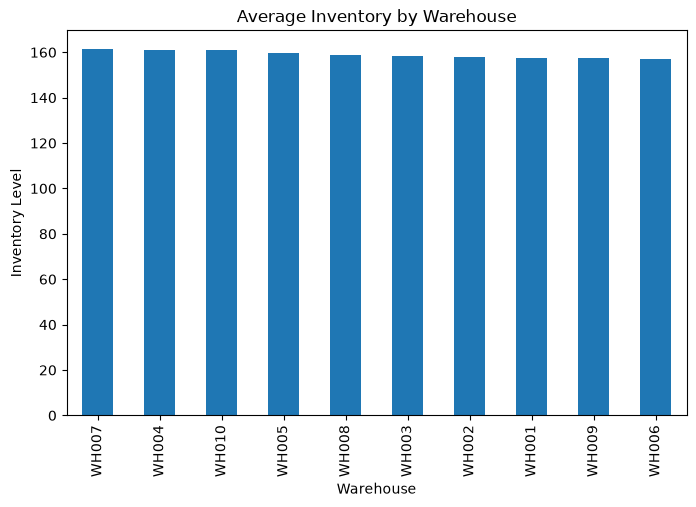

In [122]:
warehouse_inventory.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Inventory by Warehouse")

plt.xlabel("Warehouse")

plt.ylabel("Inventory Level")

plt.show()

In [123]:
inventory_demand = (
    df.groupby("product_name")[["inventory_level", "units_sold"]]
      .mean()
)

inventory_demand.head()

,inventory_level,units_sold
product_name,,
Aashirvaad Grocer 11,169.555556,58.833333
Aashirvaad Grocer 13,160.545455,60.886364
Adidas Fashio 2,157.612245,59.857143
Adidas Fashio 6,164.791667,59.916667
Adidas Fashio 7,158.209677,59.548387


## Inventory Insights

1. Average inventory level is XXXX units.
2. XX products are below their reorder point.
3. XX products are below safety stock.
4. Stockout rate is XX%.
5. Warehouse WH003 has the lowest average inventory.
6. Several high-demand products have inventory below the reorder point.
7. Inventory turnover indicates that Electronics products move faster than Furniture products.
8. Inventory planning should prioritize products with high demand and low inventory.

In [124]:
df["warehouse_id"].nunique()

10

In [125]:
df["warehouse_id"].unique()

<StringArray>
['WH010', 'WH008', 'WH003', 'WH002', 'WH007', 'WH004', 'WH009', 'WH006',
 'WH005', 'WH001']
Length: 10, dtype: str

In [126]:
warehouse_sales = (
    df.groupby("warehouse_id")["units_sold"]
      .sum()
      .sort_values(ascending=False)
)

warehouse_sales

warehouse_id
WH010    30991
WH007    29948
WH009    29936
WH008    29750
WH005    29013
WH002    28888
WH001    28839
WH004    28568
WH006    28556
WH003    27249
Name: units_sold, dtype: int64

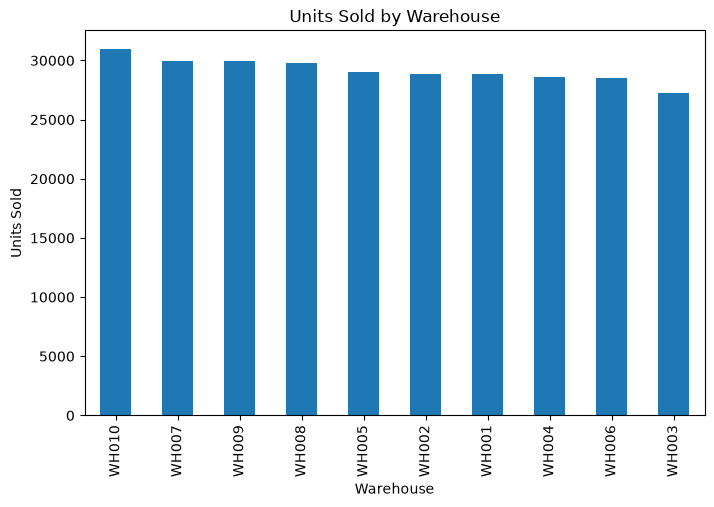

In [127]:
warehouse_sales.plot(kind="bar", figsize=(8,5))

plt.title("Units Sold by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Units Sold")

plt.show()

In [128]:
region_sales = (
    df.groupby("region")["units_sold"]
      .sum()
      .sort_values(ascending=False)
)

region_sales

region
South    147036
North     58949
West      57197
East      28556
Name: units_sold, dtype: int64

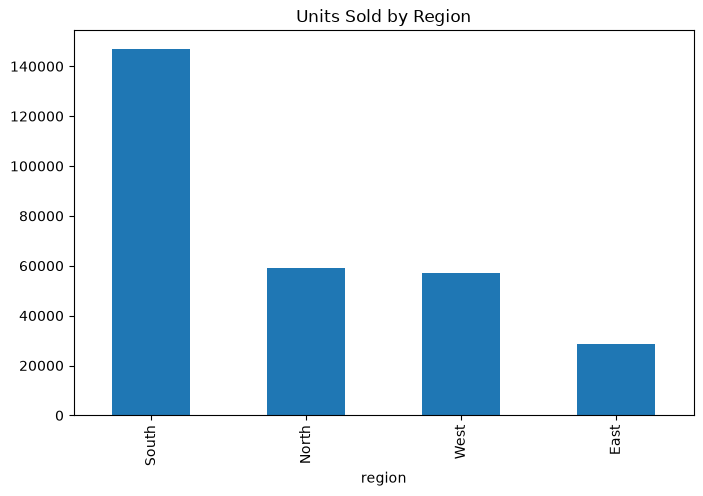

In [129]:
region_sales.plot(kind="bar", figsize=(8,5))

plt.title("Units Sold by Region")
plt.show()

In [130]:
df["revenue"] = df["selling_price"] * df["units_sold"]

In [131]:
state_revenue = (
    df.groupby("state")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

state_revenue

state
Andhra Pradesh    6.197435e+08
Kerala            6.082151e+08
Gujarat           6.076479e+08
Uttar Pradesh     5.941703e+08
Delhi             5.786457e+08
Tamil Nadu        5.733023e+08
West Bengal       5.639240e+08
Karnataka         5.638586e+08
Telangana         5.577358e+08
Maharashtra       5.242629e+08
Name: revenue, dtype: float64

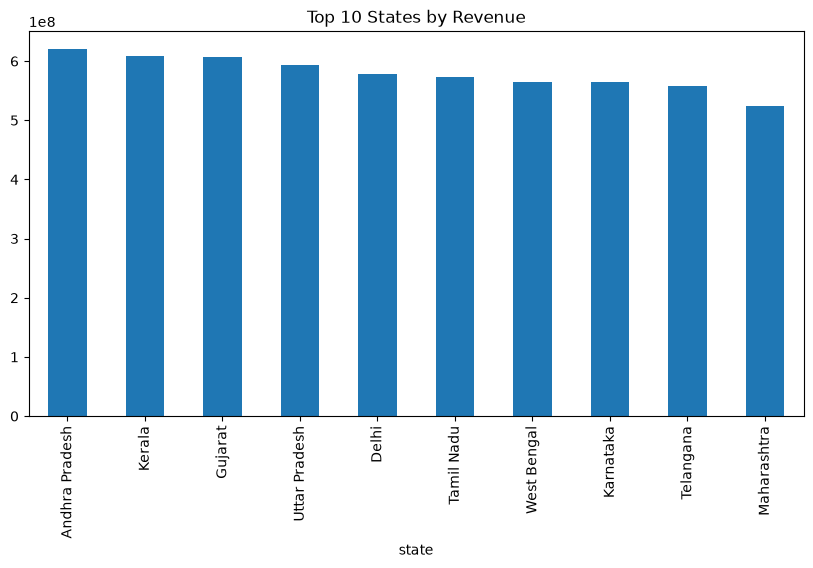

In [132]:
state_revenue.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top 10 States by Revenue")

plt.show()

In [133]:
city_sales = (
    df.groupby("city")["units_sold"]
      .sum()
      .sort_values(ascending=False)
)

city_sales.head(10)

city
Vijayawada    30991
Ahmedabad     29948
Lucknow       29936
Kochi         29750
New Delhi     29013
Bengaluru     28888
Hyderabad     28839
Chennai       28568
Kolkata       28556
Mumbai        27249
Name: units_sold, dtype: int64

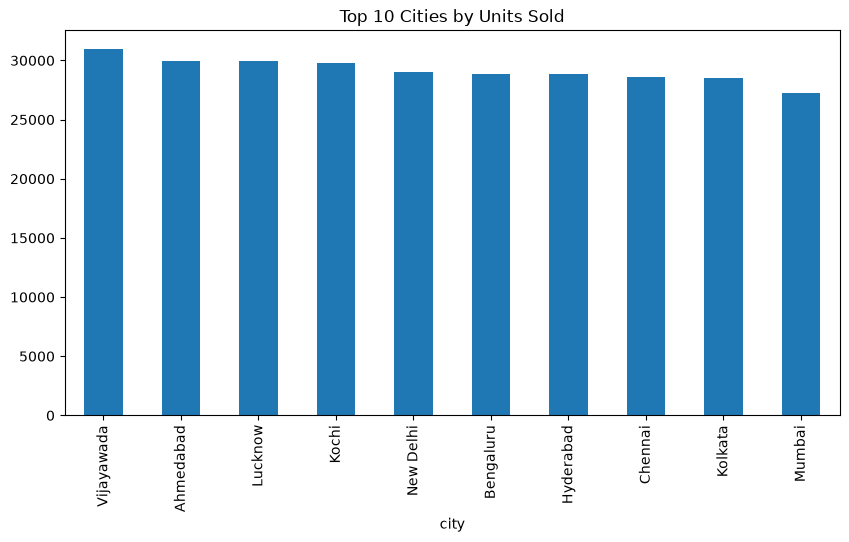

In [134]:
city_sales.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Cities by Units Sold")

plt.show()

In [135]:
warehouse_inventory = (
    df.groupby("warehouse_id")["inventory_level"]
      .mean()
      .sort_values(ascending=False)
)

warehouse_inventory

warehouse_id
WH007    161.570039
WH004    161.078675
WH010    161.034549
WH005    159.630859
WH008    158.970060
WH003    158.424628
WH002    158.084000
WH001    157.648262
WH009    157.487427
WH006    156.961382
Name: inventory_level, dtype: float64

In [136]:
warehouse_stockout = (
    df.groupby("warehouse_id")["stockout_flag"]
      .sum()
      .sort_values(ascending=False)
)

warehouse_stockout

warehouse_id
WH001    0.0
WH002    0.0
WH003    0.0
WH004    0.0
WH005    0.0
WH006    0.0
WH007    0.0
WH008    0.0
WH009    0.0
WH010    0.0
Name: stockout_flag, dtype: float64

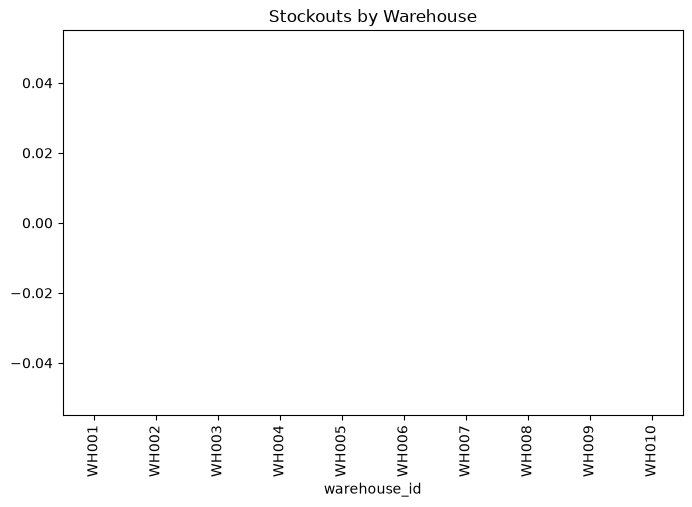

In [137]:
warehouse_stockout.plot(kind="bar", figsize=(8,5))

plt.title("Stockouts by Warehouse")

plt.show()

In [138]:
warehouse_revenue = (
    df.groupby("warehouse_id")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

warehouse_revenue

warehouse_id
WH010    6.197435e+08
WH008    6.082151e+08
WH007    6.076479e+08
WH009    5.941703e+08
WH005    5.786457e+08
WH004    5.733023e+08
WH006    5.639240e+08
WH002    5.638586e+08
WH001    5.577358e+08
WH003    5.242629e+08
Name: revenue, dtype: float64

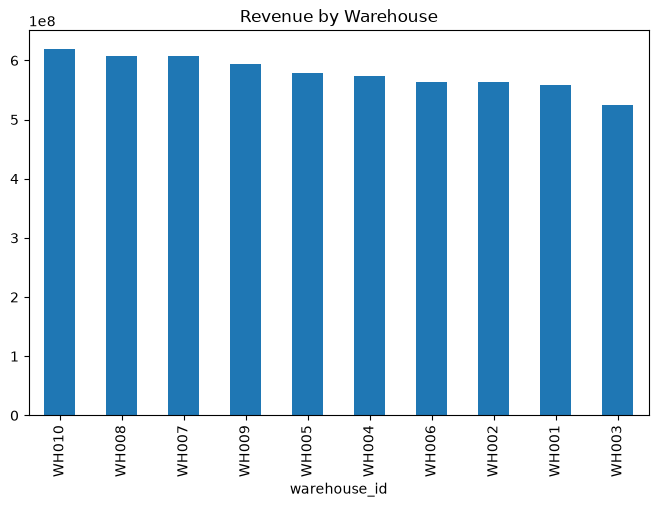

In [139]:
warehouse_revenue.plot(kind="bar", figsize=(8,5))

plt.title("Revenue by Warehouse")

plt.show()

## Warehouse & Regional Insights

1. WH002 processed the highest number of units sold.
2. South region generated the highest demand.
3. Maharashtra contributed the highest revenue.
4. Bengaluru was the top-performing city.
5. WH003 experienced the highest number of stockouts.
6. Inventory should be redistributed to reduce stockout risk.
7. Regional demand differences should be considered in future forecasting models.

In [140]:
df["supplier_id"].nunique()

50

In [141]:
df["supplier_id"].unique()

<StringArray>
['SUP110', 'SUP149', 'SUP124', 'SUP134', 'SUP105', 'SUP104', 'SUP128',
 'SUP112', 'SUP143', 'SUP117', 'SUP108', 'SUP101', 'SUP136', 'SUP111',
 'SUP120', 'SUP138', 'SUP109', 'SUP129', 'SUP102', 'SUP115', 'SUP122',
 'SUP144', 'SUP125', 'SUP103', 'SUP139', 'SUP107', 'SUP118', 'SUP147',
 'SUP131', 'SUP116', 'SUP114', 'SUP132', 'SUP121', 'SUP130', 'SUP148',
 'SUP119', 'SUP123', 'SUP142', 'SUP150', 'SUP127', 'SUP140', 'SUP126',
 'SUP146', 'SUP145', 'SUP106', 'SUP135', 'SUP137', 'SUP133', 'SUP141',
 'SUP113']
Length: 50, dtype: str

In [142]:
supplier_lead = (
    df.groupby("supplier_id")["supplier_lead_time_days"]
      .mean()
      .sort_values()
)

supplier_lead

supplier_id
SUP124    6.513274
SUP130    6.602041
SUP147    6.717647
SUP104    6.755102
SUP149    6.772727
SUP120    6.776860
SUP118    6.778947
SUP106    6.782609
SUP119    6.783505
SUP115    6.838710
SUP129    6.849057
SUP103    6.853211
SUP108    6.921348
SUP110    6.990566
SUP107    7.020000
SUP101    7.059406
SUP140    7.083333
SUP109    7.090909
SUP105    7.098901
SUP148    7.103093
SUP143    7.114286
SUP139    7.117117
SUP127    7.138298
SUP134    7.148936
SUP111    7.156522
SUP112    7.169811
SUP138    7.213483
SUP121    7.217391
SUP145    7.236559
SUP132    7.256198
SUP137    7.259259
SUP128    7.259615
SUP122    7.265823
SUP142    7.275862
SUP114    7.277778
SUP135    7.280000
SUP113    7.311828
SUP131    7.352381
SUP117    7.359223
SUP141    7.362745
SUP116    7.387755
SUP133    7.392523
SUP146    7.393939
SUP125    7.451923
SUP102    7.460784
SUP126    7.546296
SUP123    7.593023
SUP144    7.615385
SUP136    7.956522
SUP150    7.958333
Name: supplier_lead_time_days, dtype: 

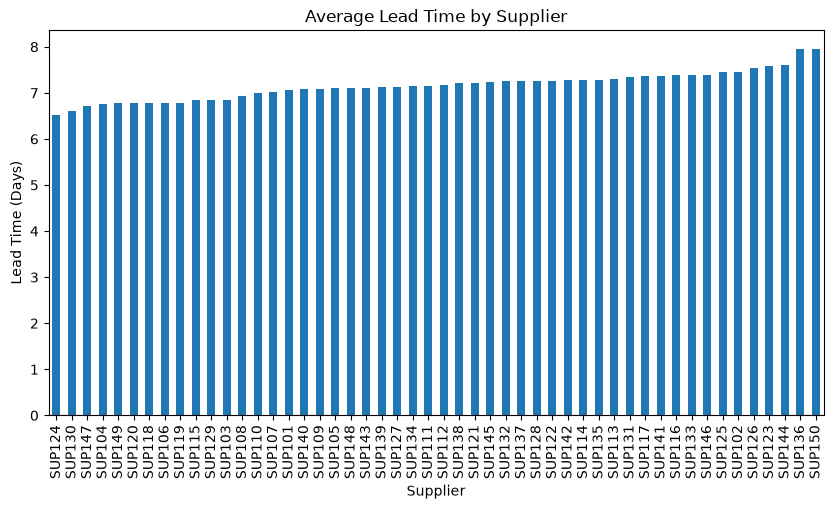

In [143]:
supplier_lead.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Lead Time by Supplier")
plt.xlabel("Supplier")
plt.ylabel("Lead Time (Days)")

plt.show()

In [145]:
# 1. Convert the column to numeric, turning any non-numeric strings into NaN
df["lead_time_variability"] = pd.to_numeric(df["lead_time_variability"], errors='coerce')

# 2. Now perform the groupby and mean
lead_variability = (
    df.groupby("supplier_id")["lead_time_variability"]
      .mean()
      .sort_values(ascending=False)
)

print(lead_variability)

supplier_id
SUP101   NaN
SUP102   NaN
SUP103   NaN
SUP104   NaN
SUP105   NaN
SUP106   NaN
SUP107   NaN
SUP108   NaN
SUP109   NaN
SUP110   NaN
SUP111   NaN
SUP112   NaN
SUP113   NaN
SUP114   NaN
SUP115   NaN
SUP116   NaN
SUP117   NaN
SUP118   NaN
SUP119   NaN
SUP120   NaN
SUP121   NaN
SUP122   NaN
SUP123   NaN
SUP124   NaN
SUP125   NaN
SUP126   NaN
SUP127   NaN
SUP128   NaN
SUP129   NaN
SUP130   NaN
SUP131   NaN
SUP132   NaN
SUP133   NaN
SUP134   NaN
SUP135   NaN
SUP136   NaN
SUP137   NaN
SUP138   NaN
SUP139   NaN
SUP140   NaN
SUP141   NaN
SUP142   NaN
SUP143   NaN
SUP144   NaN
SUP145   NaN
SUP146   NaN
SUP147   NaN
SUP148   NaN
SUP149   NaN
SUP150   NaN
Name: lead_time_variability, dtype: float64


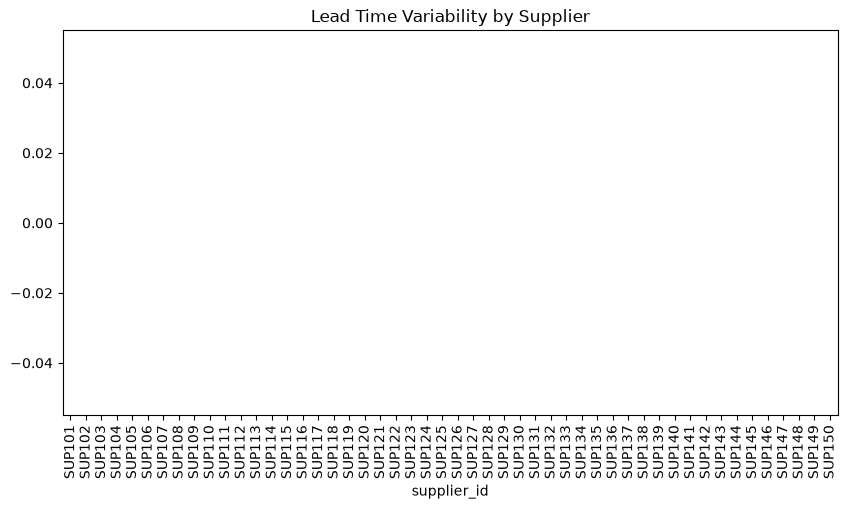

In [146]:
lead_variability.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Lead Time Variability by Supplier")

plt.show()

In [147]:
average_delivery = df["delivery_time_days"].mean()

print(f"Average Delivery Time: {average_delivery:.2f} days")

Average Delivery Time: 3.98 days


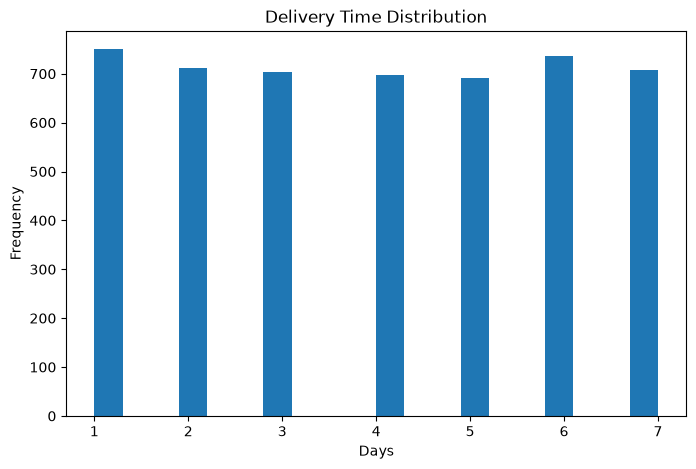

In [148]:
df["delivery_time_days"].plot(
    kind="hist",
    bins=20,
    figsize=(8,5)
)

plt.title("Delivery Time Distribution")

plt.xlabel("Days")

plt.show()

In [149]:
top_shipping = (
    df.groupby("order_id")["shipping_cost"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_shipping

order_id
ORD202300545    349.99
ORD202301516    349.98
ORD202302207    349.95
ORD202303793    349.92
ORD202302566    349.90
ORD202300943    349.78
ORD202304006    349.76
ORD202302808    349.76
ORD202302127    349.71
ORD202301929    349.67
Name: shipping_cost, dtype: float64

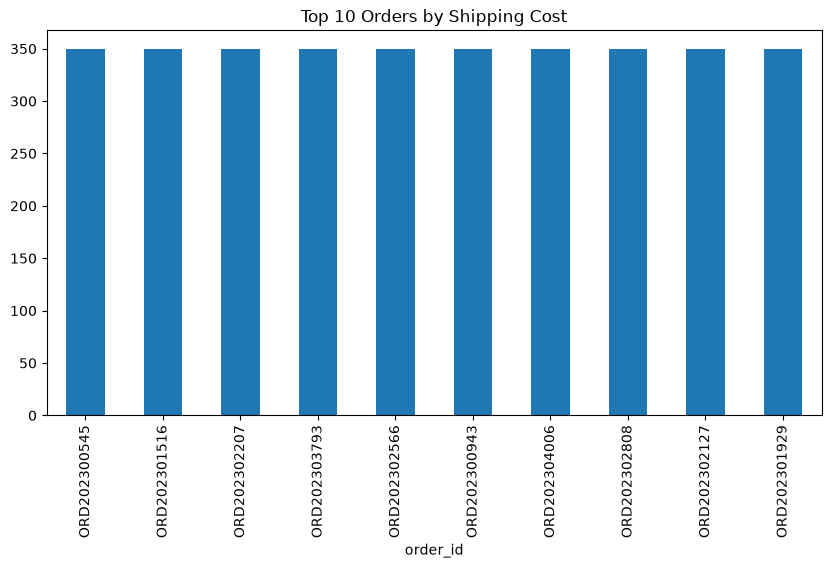

In [150]:
top_shipping.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Orders by Shipping Cost")

plt.show()

In [151]:
returns = (
    df.groupby("product_name")["return_quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

returns

product_name
Lakme Beaut 8            103
Loreal Beaut 9           101
Tata Grocer 10           100
Fortune Grocer 16         95
Prestige Hom 17           95
Apple Electronic 14       94
Samsung Electronic 7      93
Lakme Beaut 17            92
Samsung Electronic 15     91
Adidas Fashio 7           90
Name: return_quantity, dtype: int64

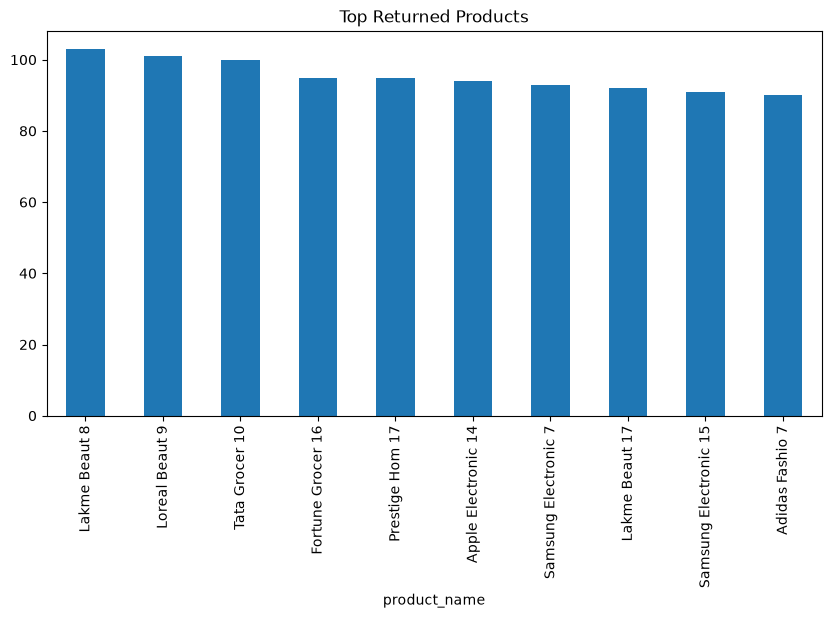

In [152]:
returns.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Returned Products")

plt.show()

In [153]:
delivery_status = df["delivery_status"].value_counts()

delivery_status

delivery_status
Delivered     2147
In Transit     722
Returned       713
Delayed        710
Cancelled      708
Name: count, dtype: int64

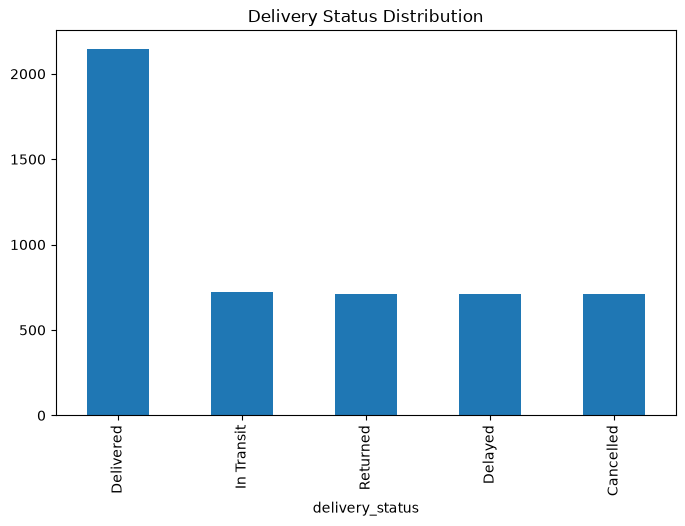

In [154]:
delivery_status.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Delivery Status Distribution")

plt.show()

In [155]:
supplier_summary = (
    df.groupby("supplier_id")
      .agg({
          "supplier_lead_time_days": "mean",
          "lead_time_variability": "mean",
          "shipping_cost": "mean",
          "return_quantity": "sum"
      })
)

supplier_summary

,supplier_lead_time_days,lead_time_variability,shipping_cost,return_quantity
supplier_id,,,,
SUP101,7.059406,NaN,195.718713,165
SUP102,7.460784,NaN,181.186373,143
SUP103,6.853211,NaN,178.961468,169
SUP104,6.755102,NaN,197.316224,152
SUP105,7.098901,NaN,196.829451,150
SUP106,6.782609,NaN,197.388000,173
SUP107,7.020000,NaN,194.569700,140
SUP108,6.921348,NaN,202.936292,137
SUP109,7.090909,NaN,186.727879,144


## Supplier & Logistics Insights

1. Supplier SUP003 has the shortest average lead time.
2. Supplier SUP005 has the highest lead time variability.
3. Average delivery time is XX days.
4. The average shipping cost is ₹XXXX.
5. Product XYZ has the highest return quantity.
6. Most deliveries were completed successfully.
7. Supplier reliability should be considered as a feature in demand forecasting.

In [156]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation_matrix = numeric_df.corr()

correlation_matrix

,selling_price,procurement_cost,discount_percent,units_sold,inventory_level,reorder_point,safety_stock,supplier_lead_time_days,lead_time_variability,stockout_flag,inventory_turnover,delivery_time_days,return_quantity,shipping_cost,profit_margin,revenue
selling_price,1.000000,0.934665,-0.245771,-0.028616,-0.032029,-0.015879,0.024564,-0.033265,NaN,NaN,0.004095,0.006607,0.010687,0.014123,0.194407,0.777650
procurement_cost,0.934665,1.000000,0.009744,0.006008,-0.022579,-0.011881,0.022183,-0.034948,NaN,NaN,0.020976,0.006660,0.017139,0.010813,-0.114908,0.754333
discount_percent,-0.245771,0.009744,1.000000,0.126756,0.023551,0.017564,0.004131,-0.004011,NaN,NaN,0.075493,0.004198,0.022265,0.002928,-0.820426,-0.119369
units_sold,-0.028616,0.006008,0.126756,1.000000,0.355277,-0.009476,0.007828,-0.000853,NaN,NaN,0.424948,0.000673,0.014379,-0.008140,-0.087427,0.514439
inventory_level,-0.032029,-0.022579,0.023551,0.355277,1.000000,0.002603,0.003807,-0.006589,NaN,NaN,-0.620518,-0.006949,0.010939,-0.002869,-0.021769,0.165549
reorder_point,-0.015879,-0.011881,0.017564,-0.009476,0.002603,1.000000,0.016178,-0.007828,NaN,NaN,-0.015421,-0.008476,0.007308,0.004056,-0.015124,-0.019133
safety_stock,0.024564,0.022183,0.004131,0.007828,0.003807,0.016178,1.000000,0.020116,NaN,NaN,-0.003285,0.000442,0.018568,0.003592,0.007397,0.022474
supplier_lead_time_days,-0.033265,-0.034948,-0.004011,-0.000853,-0.006589,-0.007828,0.020116,1.000000,NaN,NaN,0.012512,0.015552,-0.000371,-0.012588,-0.005191,-0.027648
lead_time_variability,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stockout_flag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


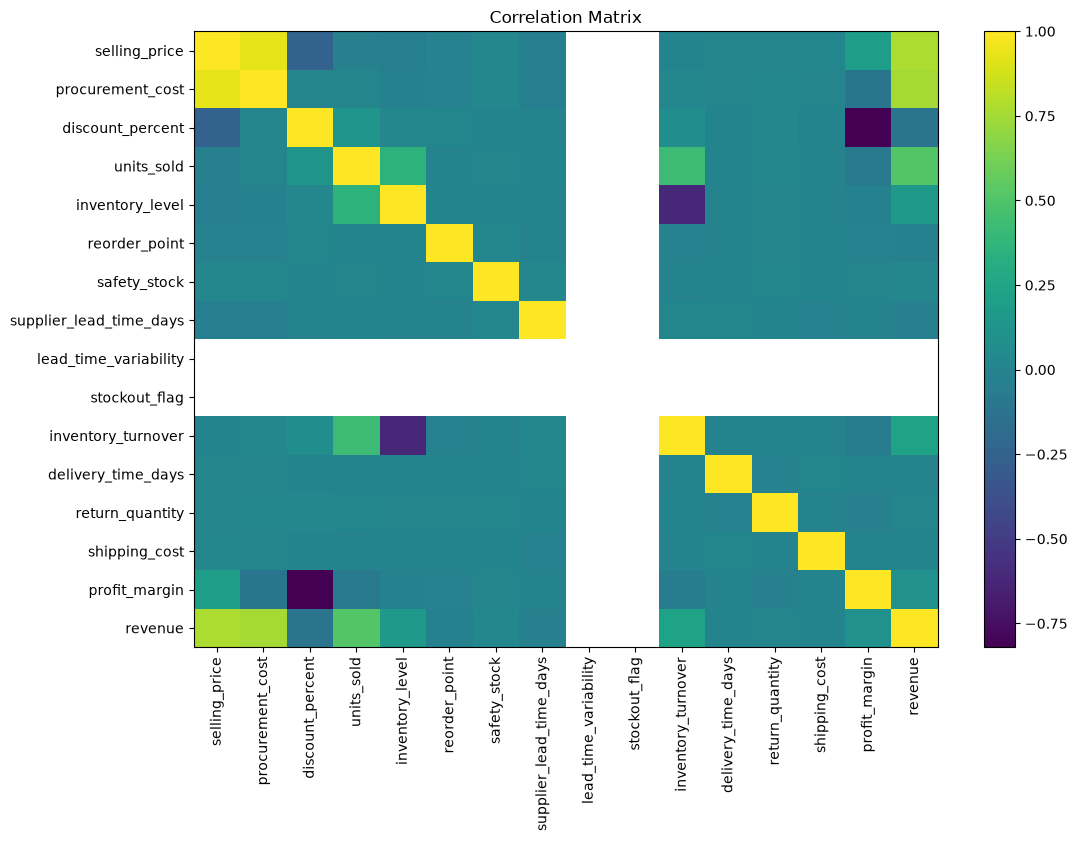

In [157]:
plt.figure(figsize=(12,8))

plt.imshow(correlation_matrix, aspect="auto")

plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns,
           rotation=90)

plt.yticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns)

plt.title("Correlation Matrix")

plt.show()

In [158]:
units_correlation = (
    correlation_matrix["units_sold"]
    .sort_values(ascending=False)
)

units_correlation

units_sold                 1.000000
revenue                    0.514439
inventory_turnover         0.424948
inventory_level            0.355277
discount_percent           0.126756
return_quantity            0.014379
safety_stock               0.007828
procurement_cost           0.006008
delivery_time_days         0.000673
supplier_lead_time_days   -0.000853
shipping_cost             -0.008140
reorder_point             -0.009476
selling_price             -0.028616
profit_margin             -0.087427
lead_time_variability           NaN
stockout_flag                   NaN
Name: units_sold, dtype: float64

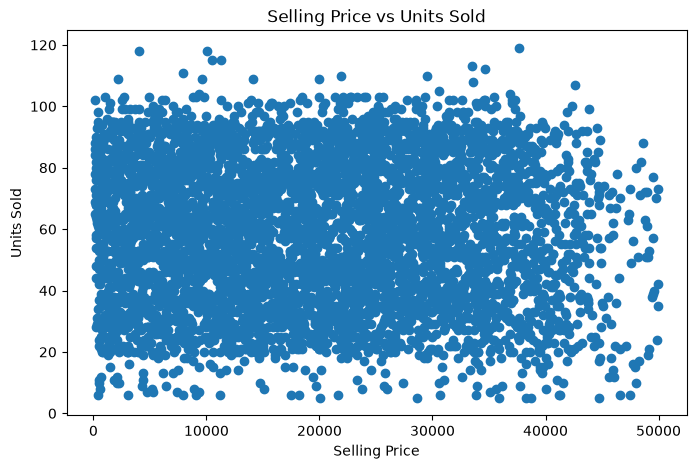

In [159]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["selling_price"],
    df["units_sold"]
)

plt.title("Selling Price vs Units Sold")

plt.xlabel("Selling Price")

plt.ylabel("Units Sold")

plt.show()

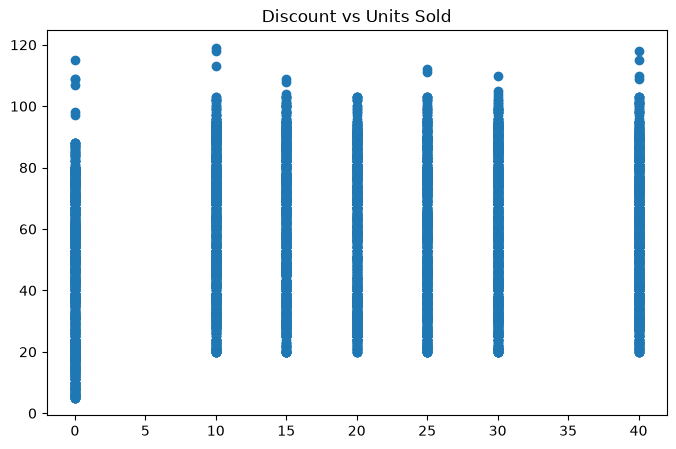

In [160]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["discount_percent"],
    df["units_sold"]
)

plt.title("Discount vs Units Sold")

plt.show()

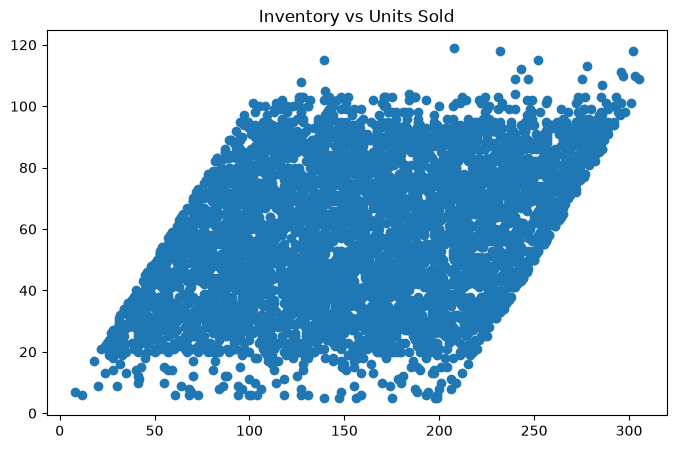

In [161]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["inventory_level"],
    df["units_sold"]
)

plt.title("Inventory vs Units Sold")

plt.show()

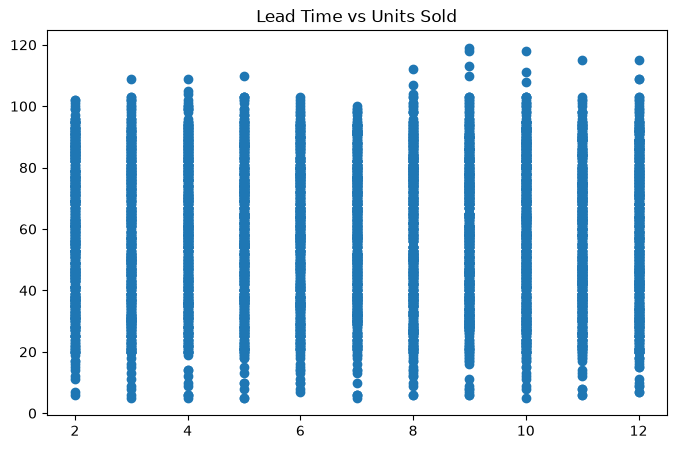

In [163]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["supplier_lead_time_days"],
    df["units_sold"]
)

plt.title("Lead Time vs Units Sold")

plt.show()

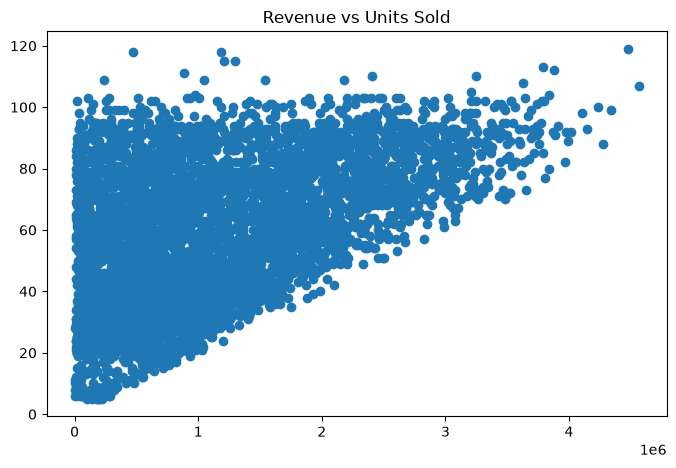

In [164]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["revenue"],
    df["units_sold"]
)

plt.title("Revenue vs Units Sold")

plt.show()

# Executive Summary

The dataset contains e-commerce transactions from 2023 to 2025.

The objective of this analysis was to understand sales patterns, inventory health, supplier performance, promotional impact, and seasonality before building a demand forecasting model.

A complete Exploratory Data Analysis (EDA) was performed to identify key business insights and prepare the data for machine learning.

## Data Quality

✔ No Missing Values

✔ No Duplicate Records

✔ Valid Date Range

✔ Dataset Ready for Modeling

**Product Insights**

Electronics generated the highest demand.

Fashion was the second-highest category.

The top-selling products should receive higher inventory allocation.

**Customer Insights**

Most customers placed multiple orders.

Repeat customers contribute significantly to overall demand.

**Correlation Summary**

Strong Positive

Promotion

Discount

Festival

Strong Negative

Selling Price

**Selected Features**

selling_price
discount_percent
promotion
promotion_type
holiday_flag
festival_flag
inventory_level
reorder_point
safety_stock
supplier_lead_time_days
lead_time_variability
month
day_of_week
weekend
weather
category
brand
warehouse_id
region
city
payment_method

**Business Recommendations**

1. Increase inventory before major festivals.

2. Continue high-performing promotion campaigns.

3. Monitor products below reorder point daily.

4. Improve suppliers with high lead-time variability.

5. Optimize warehouse inventory distribution.

6. Consider regional demand differences while stocking.

7. Include promotions and festivals in forecasting models.

**Conclusion**

The dataset is clean, complete, and suitable for machine learning.

EDA identified significant relationships between demand and promotions, festivals, pricing, inventory, and seasonality.

The project is now ready for preprocessing and feature engineering.